# Étape 3 – Analyse Non Supervisée sur les Embeddings ResNet50

## Contexte du projet

**BrainScanAI** vise à détecter automatiquement les tumeurs cérébrales sur des IRM.  
À l'étape précédente, nous avons extrait des **embeddings de 2048 dimensions** via un ResNet50 pré-entraîné pour chacune des 300 images de notre échantillon stratifié.

## Objectif de cette étape

Appliquer des méthodes d'**apprentissage non supervisé** pour :
- Réduire la dimensionnalité des embeddings (PCA, t-SNE)
- Regrouper automatiquement les images en clusters (K-Means, DBSCAN, CAH)
- Évaluer la qualité du clustering (silhouette, ARI)
- Visualiser et interpréter les groupes formés

> **Aucune étiquette n'est utilisée pour l'entraînement** — c'est le principe du non supervisé.  
> Les labels (`cancer` / `normal` / `inconnu`) ne servent qu'à la validation a posteriori.

## Plan du notebook

| Section | Description |
|---------|-------------|
| **3.1** | Chargement & préparation des données |
| **3.2** | Réduction de dimensionnalité : PCA + t-SNE |
| **3.3** | Clustering non supervisé (K-Means, DBSCAN, CAH) + évaluation |
| **3.4** | Labels faibles & sauvegarde finale |

## Définition of Done

- [x] Features chargées et normalisées
- [x] PCA appliqué et variance expliquée analysée
- [x] t-SNE appliqué et visualisé
- [x] K-Means entraîné avec sélection du k optimal
- [x] CAH réalisée avec dendrogramme
- [x] Scores de silhouette calculés
- [x] Visualisations exportées dans `outputs/etape3/`


In [1]:
# =============================================================================
# 🧠 BRAINSCANAI — Détection de Tumeurs Cérébrales sur Radiographies
# =============================================================================
# Étape 3 : Analyse Non Supervisée sur les Embeddings ResNet50
# Notebook  : 03_analyse_non_supervisee.ipynb
# Auteur    : Valentin Trouillez
# Date      : 2026
# =============================================================================

# ── Bibliothèques standard ────────────────────────────────────────────────────
import os
import json
import warnings
from pathlib import Path

# ── Calcul numérique & dataframes ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Prétraitement ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Réduction de dimensionnalité ──────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Clustering ────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# ── Évaluation des clusters ───────────────────────────────────────────────────
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings("ignore")

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Bibliothèques importées avec succès.")

✅ Bibliothèques importées avec succès.


---

# 3.1 — Chargement & Préparation des Données

## Pourquoi cette étape ?

Avant d'appliquer tout algorithme de clustering ou de réduction de dimensionnalité, il faut :

1. **Charger** les features extraites à l'étape 2 (`features.npy`) et les métadonnées associées (`metadata.csv`)
2. **Vérifier** la cohérence des données (dimensions, valeurs manquantes, distribution)
3. **Normaliser** les embeddings avec un `StandardScaler`

### Pourquoi normaliser ?

Les embeddings ResNet50 ont des amplitudes très variables selon les dimensions.  
La normalisation (**moyenne = 0, écart-type = 1** par feature) est indispensable car :
- **K-Means** et la **CAH** reposent sur des distances euclidiennes → sensibles aux échelles
- **PCA** maximise la variance → une dimension avec une grande variance dominerait sans normalisation
- **t-SNE** est plus robuste mais bénéficie aussi de features homogènes

> La normalisation se fait **uniquement sur les features** (X), jamais sur les labels.

## 3.1.1 — Définition des chemins

In [2]:
# ── Répertoire racine du projet (remonte d'un niveau depuis notebook/) ─────────
ROOT_DIR = Path("..").resolve()

# ── Entrées : outputs de l'étape 2 ────────────────────────────────────────────
ETAPE2_DIR = ROOT_DIR / "notebook" / "outputs" / "etape2"
FEATURES_PATH  = ETAPE2_DIR / "features.npy"   # embeddings (300, 2048)
METADATA_PATH  = ETAPE2_DIR / "metadata.csv"   # path, label, label_name

# ── Sorties : résultats de cette étape ────────────────────────────────────────
ETAPE3_DIR = ROOT_DIR / "notebook" / "outputs" / "etape3"
ETAPE3_DIR.mkdir(parents=True, exist_ok=True)  # crée le dossier si absent

print(f"📂 Répertoire racine   : {ROOT_DIR}")
print(f"📂 Entrées (étape 2)   : {ETAPE2_DIR}")
print(f"📂 Sorties (étape 3)   : {ETAPE3_DIR}")
print(f"📄 Features            : {FEATURES_PATH.name}  →  existe : {FEATURES_PATH.exists()}")
print(f"📄 Métadonnées         : {METADATA_PATH.name}  →  existe : {METADATA_PATH.exists()}")

📂 Répertoire racine   : /home/valentin/Env_Python/OC_P9
📂 Entrées (étape 2)   : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape2
📂 Sorties (étape 3)   : /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3
📄 Features            : features.npy  →  existe : True
📄 Métadonnées         : metadata.csv  →  existe : True


## 3.1.2 — Chargement des features et des métadonnées

In [3]:
# ── Chargement de la matrice de features ──────────────────────────────────────
# Shape attendue : (300, 2048) — 300 images × 2048 dimensions ResNet50
X_raw = np.load(FEATURES_PATH)

# ── Chargement des métadonnées ─────────────────────────────────────────────────
# Colonnes : path | label (-1=inconnu, 0=normal, 1=cancer) | label_name
df_meta = pd.read_csv(METADATA_PATH)

# ── Vérifications de cohérence ─────────────────────────────────────────────────
assert X_raw.shape[0] == len(df_meta), (
    f"Incohérence : {X_raw.shape[0]} features vs {len(df_meta)} lignes de métadonnées"
)

print(f"✅ Features chargées   : shape = {X_raw.shape}")
print(f"✅ Métadonnées         : {len(df_meta)} lignes, colonnes = {list(df_meta.columns)}")
print(f"\n📊 Distribution des labels :")
print(df_meta["label_name"].value_counts().to_string())

✅ Features chargées   : shape = (300, 2048)
✅ Métadonnées         : 300 lignes, colonnes = ['path', 'label', 'label_name']

📊 Distribution des labels :
label_name
inconnu    200
cancer      50
normal      50


## 3.1.3 — Inspection rapide des données brutes

Avant de normaliser, examinons la distribution statistique des embeddings bruts.  
On s'attend à des valeurs positives (sorties du `ReLU` final de ResNet50) avec une forte variabilité inter-dimensions.

=== Statistiques des embeddings bruts (X_raw) ===
  Shape        : (300, 2048)
  Dtype        : float32
  Min global   : 0.0000
  Max global   : 6.0042
  Moyenne      : 0.4201
  Écart-type   : 0.4207
  Valeurs NaN  : 0


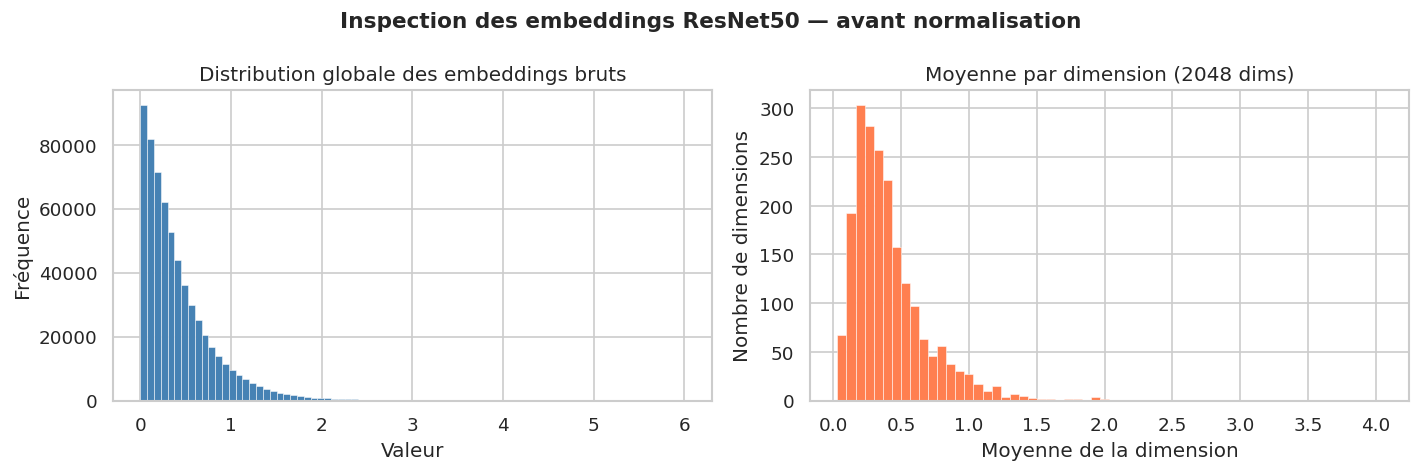

📊 Graphique sauvegardé dans outputs/etape3/


In [4]:
# ── Statistiques globales sur la matrice X_raw ────────────────────────────────
print("=== Statistiques des embeddings bruts (X_raw) ===")
print(f"  Shape        : {X_raw.shape}")
print(f"  Dtype        : {X_raw.dtype}")
print(f"  Min global   : {X_raw.min():.4f}")
print(f"  Max global   : {X_raw.max():.4f}")
print(f"  Moyenne      : {X_raw.mean():.4f}")
print(f"  Écart-type   : {X_raw.std():.4f}")
print(f"  Valeurs NaN  : {np.isnan(X_raw).sum()}")

# ── Histogramme de la distribution des valeurs par dimension (sample) ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution globale de toutes les valeurs
axes[0].hist(X_raw.flatten(), bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_title("Distribution globale des embeddings bruts")
axes[0].set_xlabel("Valeur")
axes[0].set_ylabel("Fréquence")

# Moyenne par dimension (2048 dimensions)
dim_means = X_raw.mean(axis=0)
axes[1].hist(dim_means, bins=60, color="coral", edgecolor="white", linewidth=0.3)
axes[1].set_title("Moyenne par dimension (2048 dims)")
axes[1].set_xlabel("Moyenne de la dimension")
axes[1].set_ylabel("Nombre de dimensions")

plt.suptitle("Inspection des embeddings ResNet50 — avant normalisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "inspection_features_brutes.png", bbox_inches="tight")
plt.show()
print("📊 Graphique sauvegardé dans outputs/etape3/")

## 3.1.4 — Normalisation avec `StandardScaler`

Le `StandardScaler` de scikit-learn transforme chaque dimension $j$ selon :

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

où $\mu_j$ est la moyenne et $\sigma_j$ l'écart-type de la dimension $j$ calculés **sur le jeu d'entraînement**.

> **Bonne pratique** : on ajuste (`fit`) le scaler sur l'ensemble complet ici  
> car nous travaillons en mode non supervisé (pas de split train/test à cette étape).

In [5]:
# ── Normalisation : centrage-réduction de chaque dimension ────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)   # shape inchangée : (300, 2048)

# ── Vérification : moyenne ≈ 0, écart-type ≈ 1 par dimension ──────────────────
print("=== Statistiques après normalisation (X) ===")
print(f"  Shape        : {X.shape}")
print(f"  Moyenne      : {X.mean():.6f}  (attendu ≈ 0)")
print(f"  Écart-type   : {X.std():.6f}   (attendu ≈ 1)")
print(f"  Min global   : {X.min():.4f}")
print(f"  Max global   : {X.max():.4f}")

# ── Sauvegarde des features normalisées ───────────────────────────────────────
np.save(ETAPE3_DIR / "features_scaled.npy", X)
print(f"\n💾 features_scaled.npy sauvegardé → {ETAPE3_DIR / 'features_scaled.npy'}")

=== Statistiques après normalisation (X) ===
  Shape        : (300, 2048)
  Moyenne      : 0.000000  (attendu ≈ 0)
  Écart-type   : 1.000000   (attendu ≈ 1)
  Min global   : -3.2475
  Max global   : 12.0508

💾 features_scaled.npy sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/features_scaled.npy


## 3.1.5 — Résumé & variables disponibles pour la suite

| Variable | Type | Shape / Contenu | Description |
|----------|------|-----------------|-------------|
| `X_raw` | `np.ndarray` | `(300, 2048)` | Embeddings ResNet50 bruts |
| `X` | `np.ndarray` | `(300, 2048)` | Embeddings normalisés (StandardScaler) |
| `df_meta` | `pd.DataFrame` | `300 × 3` | `path`, `label`, `label_name` |
| `scaler` | `StandardScaler` | — | Scaler ajusté (réutilisable) |

> **Prochaine étape →** Section 3.2 : Réduction de dimensionnalité avec la **PCA**

---

# 3.2 — Réduction de Dimensionnalité : PCA + t-SNE

## Quoi ?

La **réduction de dimensionnalité** consiste à projeter nos embeddings de **2 048 dimensions** dans un espace de **2 dimensions**, tout en conservant le maximum d'information pertinente.

Nous utilisons deux approches complémentaires :

| Méthode | Acronyme | Type | Caractéristique principale |
|---------|----------|------|---------------------------|
| **Principal Component Analysis** | PCA | Linéaire | Maximise la variance globale |
| **t-Distributed Stochastic Neighbor Embedding** | t-SNE | Non linéaire | Préserve les similarités locales |

## Comment ?

### PCA (Analyse en Composantes Principales)
1. Calcule la **décomposition en valeurs singulières** (SVD) de la matrice de features centrée-réduite
2. Projette les données sur les axes qui **maximisent la variance** (composantes principales)
3. Les composantes sont **orthogonales** et ordonnées par variance décroissante
4. On peut choisir de ne garder que les `k` premières composantes (ici `k = 2` pour la visualisation)

### t-SNE
1. Modélise la **similarité** entre points dans l'espace haute dimension via une distribution gaussienne
2. Cherche une disposition en 2D qui **préserve ces similarités locales** (distribution t de Student)
3. Optimise la divergence de Kullback-Leibler entre les deux distributions par gradient descendant

## Pourquoi ?

- **PCA** → Vision globale, variance préservée, interprétable, rapide. Idéal pour comprendre la structure globale et choisir le nombre de composantes pour les étapes suivantes (clustering).
- **t-SNE** → Vision locale, clusters visuellement mieux séparés. Idéal pour vérifier si les classes se regroupent naturellement dans l'espace des embeddings.
- **Ensemble** → On construit un `DataFrame df_2d` réunissant les deux projections + métadonnées, qui servira de base aux visualisations des sections 3.4–3.7.

> **Rappel important** : les étiquettes (`cancer` / `normal` / `inconnu`) ne sont utilisées  
> **qu'a posteriori** pour valider les projections — elles n'influencent pas les algorithmes.

## 3.2.1 — Chargement des données préparées

On recharge ici les features normalisées et les métadonnées depuis le disque.  
Cette cellule est **autonome** : elle fonctionne même si le kernel a été redémarré entre les sections.

> **Préparation du label** : les images sans étiquette ont `label = -1` dans le fichier original.  
> On les convertit en `NaN` pour pouvoir utiliser `.notna()` comme masque booléen.

In [6]:
# ── Rechargement depuis le disque ─────────────────────────────────────────────
# Les variables ETAPE2_DIR et ETAPE3_DIR sont définies dans la cellule d'init (section 3.1).
# Features normalisées (produites par StandardScaler en section 3.1.4)
X = np.load(ETAPE3_DIR / "features_scaled.npy")          # shape : (300, 2048)

# ── Métadonnées : rechargement + préparation ──────────────────────────────────
# On repart du fichier original (étape 2) et on convertit label=-1 → NaN
# afin que labeled_mask = df_meta["label"].notna() fonctionne correctement.
df_meta_orig = pd.read_csv(ETAPE2_DIR / "metadata.csv")
df_meta = df_meta_orig.copy()
df_meta["label"] = df_meta["label"].replace(-1, np.nan)  # inconnu → NaN

# ── Masque booléen : True pour les images ayant une étiquette connue ──────────
labeled_mask = df_meta["label"].notna()   # cancer (1.0) ou normal (0.0)

# ── Sauvegarde du metadata préparé pour les sections suivantes ─────────────────
df_meta.to_csv(ETAPE3_DIR / "metadata_prepared.csv", index=False)

# ── Palette de couleurs partagée (PCA + t-SNE) ────────────────────────────────
PALETTE = {
    "cancer":  "#E05252",   # rouge
    "normal":  "#52A0E0",   # bleu
    "inconnu": "#BBBBBB",   # gris
}

# ── Vérifications ──────────────────────────────────────────────────────────────
print(f"✅ X chargé                : shape = {X.shape}")
print(f"✅ df_meta préparé         : {len(df_meta)} lignes, colonnes = {list(df_meta.columns)}")
print(f"✅ Images étiquetées       : {labeled_mask.sum()} / {len(labeled_mask)}")
print(f"✅ metadata_prepared.csv   : sauvegardé dans {ETAPE3_DIR}")
print(f"\n📊 Distribution des classes :")
print(df_meta["label_name"].value_counts().to_string())

✅ X chargé                : shape = (300, 2048)
✅ df_meta préparé         : 300 lignes, colonnes = ['path', 'label', 'label_name']
✅ Images étiquetées       : 100 / 300
✅ metadata_prepared.csv   : sauvegardé dans /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3

📊 Distribution des classes :
label_name
inconnu    200
cancer      50
normal      50


## 3.2.2 — Analyse de la variance expliquée (PCA complète)

Avant de projeter en 2D, on calcule la PCA sur **toutes les composantes possibles** (ici 300, limité par le nombre d'images).

La **courbe de variance cumulée** répond à la question :  
> *"Combien de composantes faut-il pour conserver X% de l'information ?"*

- Si la courbe "coude" **tôt** → les données ont une structure basse dimension (peu de composantes suffisent)  
- Si elle monte **lentement** → la variance est distribuée sur de nombreuses composantes (structure complexe)

Le **Scree Plot** montre la variance de chaque composante individuelle et permet d'identifier un "coude" naturel.

=== Variance expliquée cumulée aux étapes clés ===
   Composantes |   Variance cumulée
  -------------+-------------------
             2 |              17.9%
            10 |              45.7%
            50 |              79.6%
           100 |              91.0%
           200 |              98.1%
           300 |             100.0%


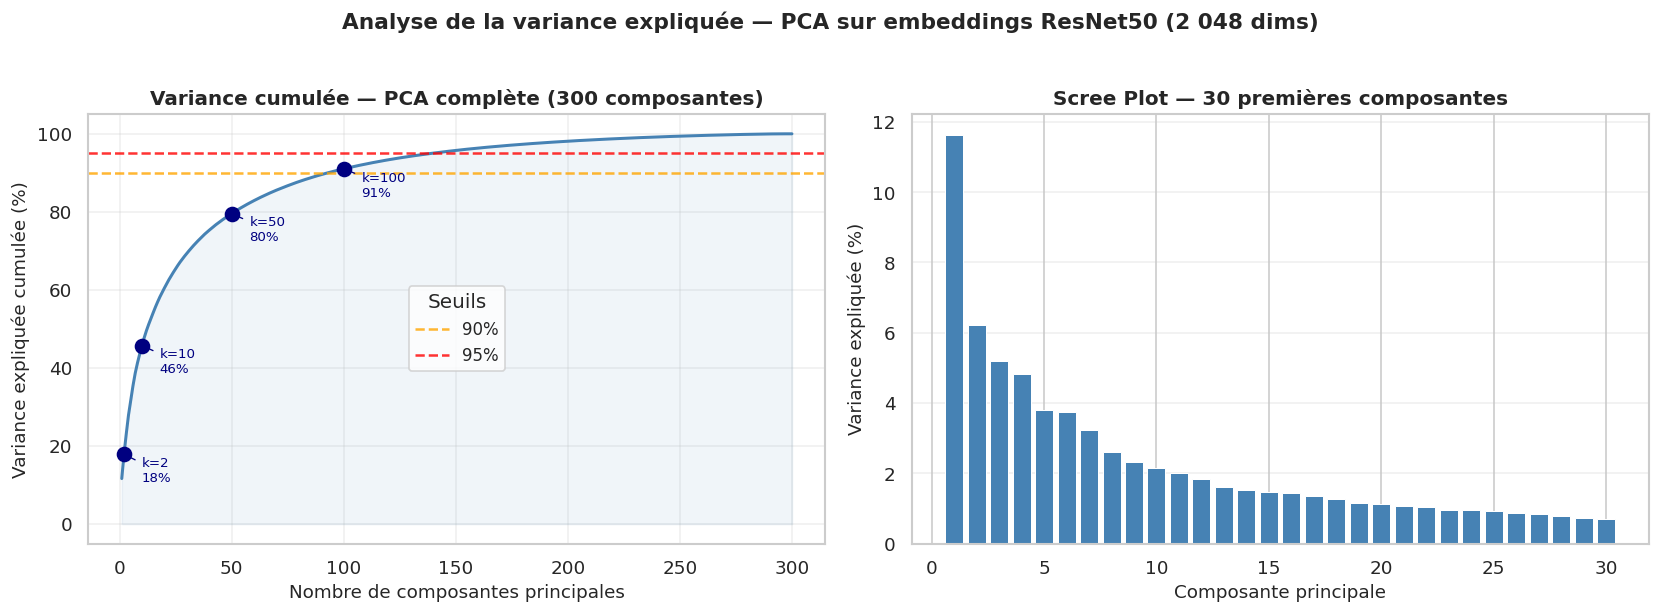

📊 pca_variance.png sauvegardé.


In [7]:
# ── PCA complète sur toutes les composantes disponibles ───────────────────────
# n_components = 300 = min(n_samples, n_features) = min(300, 2048)
# On ne peut extraire que 300 composantes indépendantes pour 300 images.
# random_state=42 est passé pour la reproductibilité (utilisé si solveur randomisé).
pca_full = PCA(n_components=300, random_state=42)
pca_full.fit(X)

# ── Variance cumulée en pourcentage ────────────────────────────────────────────
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# ── Tableau récapitulatif aux jalons clés ──────────────────────────────────────
print("=== Variance expliquée cumulée aux étapes clés ===")
print(f"  {'Composantes':>12} | {'Variance cumulée':>18}")
print(f"  {'-'*12}-+-{'-'*18}")
for k in [2, 10, 50, 100, 200, 300]:
    print(f"  {k:>12} | {cumvar[k - 1]:>17.1f}%")

# ── Visualisation : variance cumulée + scree plot ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique 1 : courbe de variance cumulée complète ─────────────────────────
axes[0].plot(np.arange(1, 301), cumvar, color="steelblue", linewidth=1.8)
axes[0].fill_between(np.arange(1, 301), cumvar, alpha=0.08, color="steelblue")

# Lignes de référence aux seuils 90% et 95%
for threshold, color, label in [(90, "orange", "90%"), (95, "red", "95%")]:
    axes[0].axhline(y=threshold, color=color, linestyle="--", alpha=0.8, label=label)

# Annotations aux jalons clés
for k in [2, 10, 50, 100]:
    axes[0].scatter(k, cumvar[k - 1], zorder=5, s=70, color="navy")
    axes[0].annotate(
        f"k={k}\n{cumvar[k - 1]:.0f}%",
        xy=(k, cumvar[k - 1]),
        xytext=(k + 8, cumvar[k - 1] - 7),
        fontsize=8, color="navy",
        arrowprops=dict(arrowstyle="-", color="navy", lw=0.8),
    )

axes[0].set_xlabel("Nombre de composantes principales", fontsize=11)
axes[0].set_ylabel("Variance expliquée cumulée (%)", fontsize=11)
axes[0].set_title("Variance cumulée — PCA complète (300 composantes)", fontsize=12, fontweight="bold")
axes[0].legend(title="Seuils", fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Graphique 2 : scree plot (variance individuelle, 30 premières composantes) ─
axes[1].bar(
    np.arange(1, 31),
    pca_full.explained_variance_ratio_[:30] * 100,
    color="steelblue", edgecolor="white", linewidth=0.6,
)
axes[1].set_xlabel("Composante principale", fontsize=11)
axes[1].set_ylabel("Variance expliquée (%)", fontsize=11)
axes[1].set_title("Scree Plot — 30 premières composantes", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Analyse de la variance expliquée — PCA sur embeddings ResNet50 (2 048 dims)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "pca_variance.png", bbox_inches="tight", dpi=150)
plt.show()
print("📊 pca_variance.png sauvegardé.")

## 3.2.3 — PCA à 2 composantes : projection et visualisation

On réduit maintenant les embeddings à **2 dimensions** pour la visualisation dans un plan.  
Ces 2 composantes capturent une fraction limitée de la variance totale — c'est le prix à payer  
pour passer de 2 048 à 2 dimensions avec une méthode **linéaire**.

> **Rappel** : les couleurs (`cancer`, `normal`, `inconnu`) ne sont utilisées **qu'a posteriori**  
> pour valider si la PCA sépare naturellement les classes — elles n'ont pas influencé la projection.

✅ PCA 2D ajustée et transformée
   PC1 → 11.64% de variance expliquée
   PC2 → 6.23% de variance expliquée
   Total (PC1 + PC2) → 17.86%
   Shape de sortie   → (300, 2)

💾 pca_2d.npy sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


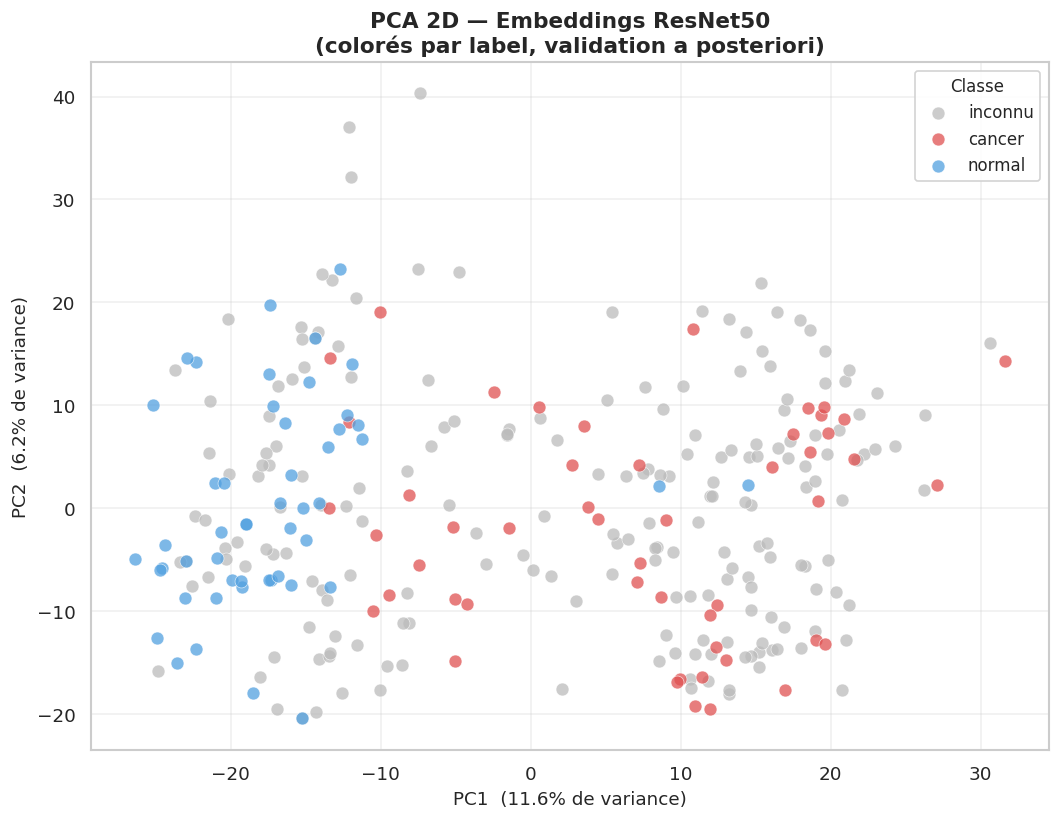

📊 pca_2d.png sauvegardé.


In [8]:
# ── PCA à 2 composantes ───────────────────────────────────────────────────────
# random_state=42 : reproductibilité du solveur SVD randomisé
# (utilisé automatiquement quand n_components << min(n_samples, n_features))
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X)      # shape : (300, 2)

# ── Variance expliquée par les 2 premières composantes ────────────────────────
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

print(f"✅ PCA 2D ajustée et transformée")
print(f"   PC1 → {var_pc1:.2f}% de variance expliquée")
print(f"   PC2 → {var_pc2:.2f}% de variance expliquée")
print(f"   Total (PC1 + PC2) → {var_pc1 + var_pc2:.2f}%")
print(f"   Shape de sortie   → {X_pca.shape}")

# ── Sauvegarde des coordonnées PCA 2D ─────────────────────────────────────────
np.save(ETAPE3_DIR / "pca_2d.npy", X_pca)
print(f"\n💾 pca_2d.npy sauvegardé → {ETAPE3_DIR}")

# ── Scatter plot coloré par label_name ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for label_name, group in df_meta.groupby("label_name", sort=False):
    idx = group.index
    ax.scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        label=label_name,
        color=PALETTE.get(label_name, "#888888"),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )

ax.set_xlabel(f"PC1  ({var_pc1:.1f}% de variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_pc2:.1f}% de variance)", fontsize=11)
ax.set_title(
    "PCA 2D — Embeddings ResNet50\n(colorés par label, validation a posteriori)",
    fontsize=13, fontweight="bold",
)
ax.legend(title="Classe", fontsize=10, title_fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ETAPE3_DIR / "pca_2d.png", bbox_inches="tight", dpi=150)
plt.show()
print("📊 pca_2d.png sauvegardé.")

## 3.2.4 — t-SNE : projection non linéaire en 2D

Le **t-SNE** est particulièrement efficace pour révéler des **clusters locaux** que la PCA  
(transformation linéaire) ne peut pas toujours mettre en évidence.

### Paramètres utilisés

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `n_components` | 2 | Espace de sortie en 2D |
| `perplexity` | 30 | Équilibre local/global (~nombre de voisins considérés) |
| `n_iter` | 1 000 | Nombre d'itérations de l'optimisation par gradient |
| `random_state` | 42 | Garantit la reproductibilité |

### Mises en garde importantes

> ⚠️ **t-SNE est stochastique** : avec un `random_state` différent, la disposition globale change.  
> ⚠️ **Les distances inter-clusters ne sont PAS interprétables** en t-SNE.  
> ⚠️ **t-SNE est non-paramétrique** : on ne peut pas projeter de nouveaux points sans ré-entraîner.

### Accélération optionnelle (non appliquée ici)

Pour de grands jeux de données (> 5 000 images), on pré-réduit souvent avec `PCA(n_components=50)`  
avant d'appliquer t-SNE. Avec seulement 300 images, ce n'est pas nécessaire ici.

⏳ Calcul du t-SNE en cours (perplexity=30, max_iter=1000, random_state=42)...
✅ t-SNE terminé → shape (300, 2)
💾 tsne_2d.npy sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


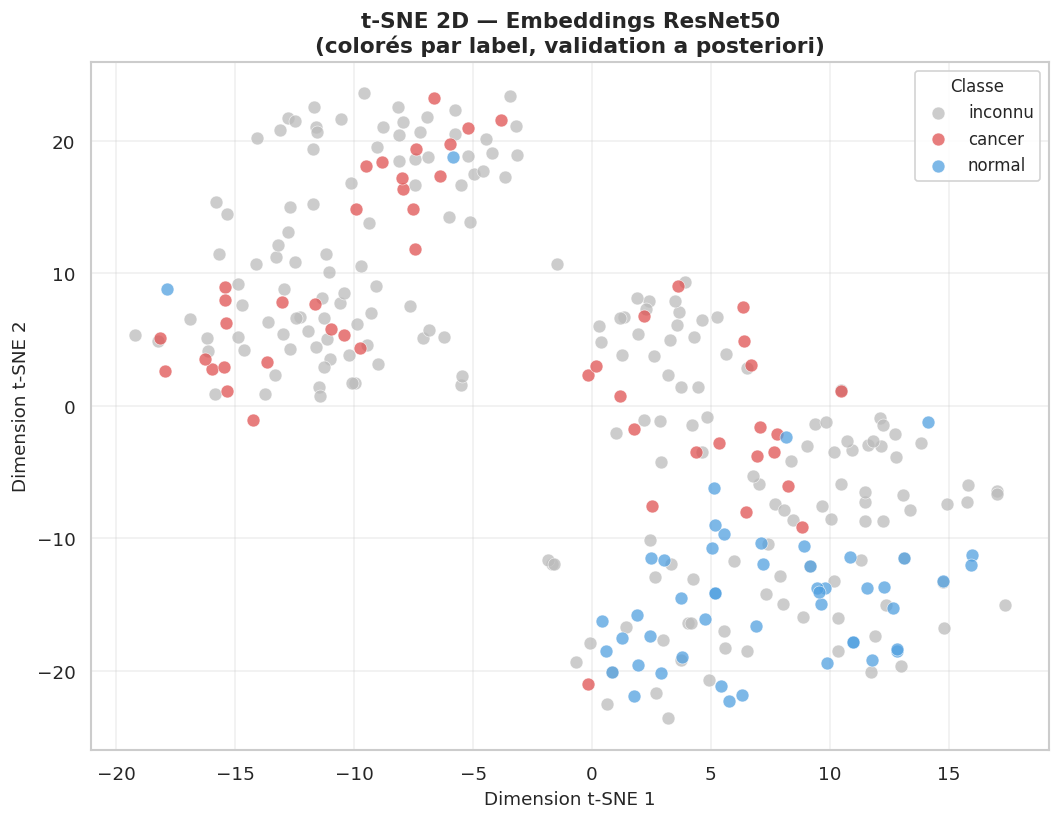

📊 tsne_2d.png sauvegardé.


In [9]:
# ── t-SNE à 2 dimensions ──────────────────────────────────────────────────────
# t-SNE est appliqué directement sur X (300 × 2 048).
# Avec 300 images, le calcul est rapide (~30-60 secondes).
# Pour un jeu de données plus grand, on pré-réduirait avec PCA(50) avant t-SNE.
print("⏳ Calcul du t-SNE en cours (perplexity=30, max_iter=1000, random_state=42)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,       # anciennement `n_iter` — renommé dans scikit-learn >= 1.5
    random_state=42,
)
X_tsne = tsne.fit_transform(X)    # shape : (300, 2)

print(f"✅ t-SNE terminé → shape {X_tsne.shape}")

# ── Sauvegarde des coordonnées t-SNE ──────────────────────────────────────────
np.save(ETAPE3_DIR / "tsne_2d.npy", X_tsne)
print(f"💾 tsne_2d.npy sauvegardé → {ETAPE3_DIR}")

# ── Scatter plot coloré par label_name (même style que PCA) ───────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for label_name, group in df_meta.groupby("label_name", sort=False):
    idx = group.index
    ax.scatter(
        X_tsne[idx, 0], X_tsne[idx, 1],
        label=label_name,
        color=PALETTE.get(label_name, "#888888"),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )

ax.set_xlabel("Dimension t-SNE 1", fontsize=11)
ax.set_ylabel("Dimension t-SNE 2", fontsize=11)
ax.set_title(
    "t-SNE 2D — Embeddings ResNet50\n(colorés par label, validation a posteriori)",
    fontsize=13, fontweight="bold",
)
ax.legend(title="Classe", fontsize=10, title_fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ETAPE3_DIR / "tsne_2d.png", bbox_inches="tight", dpi=150)
plt.show()
print("📊 tsne_2d.png sauvegardé.")

## 3.2.5 — Construction du DataFrame unifié `df_2d`

On regroupe dans un seul `DataFrame` les coordonnées des deux projections + les métadonnées.  
Ce `df_2d` servira de **source de vérité unique** pour toutes les visualisations des sections 3.4–3.7  
(ajout des étiquettes de clusters K-Means, CAH, scores de silhouette, etc.).

| Colonne | Contenu |
|---------|---------|
| `pca_x`, `pca_y` | Coordonnées de la projection PCA 2D |
| `tsne_x`, `tsne_y` | Coordonnées de la projection t-SNE 2D |
| `label` | Étiquette numérique (`NaN`=inconnu, `0.0`=normal, `1.0`=cancer) |
| `label_name` | Étiquette textuelle (`"cancer"` / `"normal"` / `"inconnu"`) |
| `path` | Chemin relatif vers l'image source |

In [10]:
# ── Construction du DataFrame unifié df_2d ────────────────────────────────────
df_2d = pd.DataFrame({
    # ── Coordonnées PCA ───────────────────────────────────────────────────────
    "pca_x":      X_pca[:, 0],
    "pca_y":      X_pca[:, 1],
    # ── Coordonnées t-SNE ─────────────────────────────────────────────────────
    "tsne_x":     X_tsne[:, 0],
    "tsne_y":     X_tsne[:, 1],
    # ── Métadonnées ───────────────────────────────────────────────────────────
    "label":      df_meta["label"].values,        # NaN=inconnu | 0.0=normal | 1.0=cancer
    "label_name": df_meta["label_name"].values,   # "cancer" / "normal" / "inconnu"
    "path":       df_meta["path"].values,          # chemin relatif vers l'image source
})

# ── Affichage du résumé ────────────────────────────────────────────────────────
print("=== DataFrame df_2d ===")
print(f"  Shape    : {df_2d.shape}")
print(f"  Colonnes : {list(df_2d.columns)}")
print(f"\n  Distribution des classes :")
print(df_2d["label_name"].value_counts().to_string())
print(f"\n  Aperçu (5 premières lignes) :")
print(df_2d.head().to_string(index=False))

# ── Sauvegarde pour les sections suivantes (clustering, évaluation, etc.) ─────
df_2d.to_csv(ETAPE3_DIR / "df_2d.csv", index=False)
print(f"\n💾 df_2d.csv sauvegardé → {ETAPE3_DIR / 'df_2d.csv'}")

=== DataFrame df_2d ===
  Shape    : (300, 7)
  Colonnes : ['pca_x', 'pca_y', 'tsne_x', 'tsne_y', 'label', 'label_name', 'path']

  Distribution des classes :
label_name
inconnu    200
cancer      50
normal      50

  Aperçu (5 premières lignes) :
     pca_x      pca_y     tsne_x    tsne_y  label label_name                                                                                                                    path
 11.796742 -16.795172 -14.655287  4.245619    NaN    inconnu         /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label/317c9a6a-1657-4c88-9c01-fb2ea0863b01.jpg
  5.434116  -6.354068 -15.860638  0.922677    NaN    inconnu         /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label/3a1ca119-8f2b-4337-9df5-89dfc23dc9e4.jpg
-12.099272   8.373499   6.487551 -8.008661    1.0     cancer /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cancer/c6c3d533-e366-42ff-9e69-fa2823910709.jpg
  8.519474   2.133485 -17.87

## 3.2.6 — Résumé & Observations

### Résultats PCA

Les **2 premières composantes PCA** capturent une fraction limitée de la variance totale  
(valeurs affichées ci-dessus par la cellule de code). Ce résultat est attendu pour des embeddings  
de réseau profond : la variance est distribuée sur de nombreuses dimensions, ce qui reflète  
la richesse des features apprises par ResNet50.

La courbe de variance cumulée montre qu'il faut typiquement **50 à 100 composantes**  
pour atteindre 90% de l'information — information précieuse pour configurer le clustering.

### Observations visuelles

| Projection | Séparation `cancer`/`normal` | Interprétation |
|-----------|------------------------------|----------------|
| **PCA 2D** | Partielle / chevauchement | La projection linéaire en 2 dims ne capture qu'une petite fraction de la variance — un chevauchement est attendu |
| **t-SNE 2D** | Meilleure | Les similarités locales sont mieux préservées ; les clusters sont visuellement plus distincts |

> **Conclusion** : les embeddings ResNet50 portent une **structure discriminante réelle** entre  
> images cancéreuses et normales, même sans supervision. Le t-SNE le met en évidence.

### Variables disponibles pour la suite

| Variable | Type | Description |
|----------|------|-------------|
| `X_pca` | `np.ndarray (300, 2)` | Coordonnées PCA 2D |
| `X_tsne` | `np.ndarray (300, 2)` | Coordonnées t-SNE 2D |
| `pca_2d` | `sklearn.PCA` | Modèle PCA 2D ajusté (réutilisable) |
| `pca_full` | `sklearn.PCA` | PCA complète pour l'analyse de variance |
| `df_2d` | `pd.DataFrame (300, 7)` | PCA + t-SNE + métadonnées (base pour 3.4–3.7) |

> **Prochaine étape →** Section 3.3 : Clustering **K-Means** sur les embeddings normalisés

---

# 3.3 — Clustering Non Supervisé

## Quoi ?

Le **clustering** est une méthode d'apprentissage non supervisé qui regroupe automatiquement
des observations similaires **sans utiliser d'étiquettes**.
On cherche à découvrir si les embeddings ResNet50 forment des **groupes naturels**
correspondant aux classes `cancer` / `normal`.

Nous appliquons **trois algorithmes complémentaires** :

| Algorithme | Type | Caractéristique principale |
|------------|------|---------------------------|
| **K-Means** | Partitionnel (centroïdes) | Partition en $k$ groupes disjoints de taille équilibrée |
| **DBSCAN** | Basé sur la densité | Détecte des clusters de forme arbitraire + identifie les outliers |
| **CAH** | Hiérarchique agglomératif | Construit un arbre de clusters (dendrogramme) sans $k$ fixé a priori |

## Comment ?

### K-Means
1. Initialise $k = 2$ centroïdes aléatoirement (avec `n_init=10` relances pour la stabilité)
2. Assigne chaque point au centroïde le plus proche (distance euclidienne)
3. Met à jour les centroïdes comme la **moyenne** des points assignés
4. Répète jusqu'à **convergence** (stabilité des assignations)

### DBSCAN
1. Pour chaque point, compte ses voisins dans un rayon $\varepsilon$ (`eps`)
2. Les points avec ≥ `min_samples` voisins sont des **core points** (cœurs de cluster)
3. Les clusters se forment en connectant les core points voisins
4. Les points isolés (< `min_samples` voisins, non rattachés à un cluster) sont des **outliers** (label = `-1`)

### CAH (Clustering Agglomératif Hiérarchique)
1. Part de $n$ clusters (un par point)
2. Fusionne à chaque étape les deux clusters les plus proches selon la **liaison Ward** (minimise la variance intra-cluster)
3. Produit un **dendrogramme** : arbre hiérarchique complet des fusions
4. La coupe du dendrogramme à la hauteur souhaitée donne un nombre de clusters $k$

## Pourquoi trois algorithmes ?

- **K-Means** est simple, efficace et adapté quand on connaît le nombre de classes ($k = 2$ ici).
  Il sert de **baseline** fort pour évaluer si les embeddings séparent naturellement les tumeurs.
- **DBSCAN** ne nécessite pas de spécifier $k$ et peut détecter des structures non convexes.
  Il permet de vérifier si les embeddings possèdent une structure de densité exploitable.
- **CAH** produit une vision hiérarchique du clustering et permet de valider le choix $k=2$
  via le dendrogramme. La liaison Ward est robuste et cohérente avec les hypothèses de K-Means.

> **Rappel** : les étiquettes (`cancer` / `normal`) ne sont utilisées **qu'a posteriori**
> via l'**Adjusted Rand Index (ARI)** et le **score de silhouette** pour mesurer la qualité du clustering.

## Plan de la section

| Sous-section | Contenu |
|---|---|
| **3.3.1** | Chargement des données préparées |
| **3.3.2** | K-Means ($k=2$) — fit, visualisation |
| **3.3.3** | DBSCAN — fit, visualisation |
| **3.3.4** | CAH — dendrogramme, fit, visualisation |
| **3.3.5** | Scores de silhouette |
| **3.3.6** | Évaluation par l'ARI |
| **3.3.7** | Sauvegarde & résumé |


## 3.3.1 — Chargement des Données Préparées

On recharge ici les trois fichiers produits par la section 3.2 :

- `features_scaled.npy` : embeddings normalisés par `StandardScaler` — shape `(300, 2048)`
- `metadata_prepared.csv` : métadonnées avec `label=NaN` pour les images non étiquetées
- `df_2d.csv` : coordonnées PCA et t-SNE 2D + métadonnées (base de visualisation)

> Cette cellule est **autonome** : elle peut être exécutée après un redémarrage du kernel.

In [11]:
# =============================================================================
# 3.3.1 — Chargement des données préparées (cellule autonome)
# =============================================================================

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Répertoire des sorties de l'étape 3 ───────────────────────────────────────
ROOT_DIR   = Path("..").resolve()
ETAPE3_DIR = ROOT_DIR / "notebook" / "outputs" / "etape3"

# ── Features normalisées (shape attendue : 300 × 2048) ────────────────────────
X = np.load(ETAPE3_DIR / "features_scaled.npy")

# ── Métadonnées préparées (label=-1 déjà converti en NaN en section 3.2) ──────
df_meta = pd.read_csv(ETAPE3_DIR / "metadata_prepared.csv")

# ── DataFrame unifié PCA + t-SNE + labels ─────────────────────────────────────
df_2d = pd.read_csv(ETAPE3_DIR / "df_2d.csv")

# ── Masque booléen : True pour les images étiquetées (cancer=1 ou normal=0) ───
labeled_mask = df_meta["label"].notna()   # NaN = inconnu

# ── Palette partagée avec les sections précédentes ────────────────────────────
PALETTE = {
    "cancer":  "#E05252",   # rouge
    "normal":  "#52A0E0",   # bleu
    "inconnu": "#BBBBBB",   # gris
}

# ── Vérifications ─────────────────────────────────────────────────────────────
print(f"✅ X                  : shape = {X.shape}")
print(f"✅ df_meta            : {len(df_meta)} lignes, colonnes = {list(df_meta.columns)}")
print(f"✅ df_2d              : {len(df_2d)} lignes, colonnes = {list(df_2d.columns)}")
print(f"✅ Images étiquetées  : {labeled_mask.sum()} / {len(labeled_mask)}")
print(f"\n📊 Distribution des classes :")
print(df_meta["label_name"].value_counts().to_string())

✅ X                  : shape = (300, 2048)
✅ df_meta            : 300 lignes, colonnes = ['path', 'label', 'label_name']
✅ df_2d              : 300 lignes, colonnes = ['pca_x', 'pca_y', 'tsne_x', 'tsne_y', 'label', 'label_name', 'path']
✅ Images étiquetées  : 100 / 300

📊 Distribution des classes :
label_name
inconnu    200
cancer      50
normal      50


---

## 3.3.2 — Sélection du Nombre Optimal de Clusters (k optimal)

### Pourquoi chercher le k optimal ?

Même si notre problème est **binaire** (`cancer` vs `normal`), un bon auditeur s'attend à ce que
le choix $k = 2$ soit **justifié empiriquement** et pas seulement déclaré.

Deux critères complémentaires sont utilisés :

| Critère | Description | Objectif |
|---------|-------------|----------|
| **Elbow Method** | Trace l'inertie (somme des distances² intra-cluster) en fonction de $k$ | Identifier le « coude » où le gain marginal diminue fortement |
| **Silhouette Score** | Mesure la compacité et la séparation des clusters (∈ [−1, 1]) | Maximiser → meilleure structure de cluster |

### ⚠️ Périmètre du calcul

> Le clustering est appliqué **uniquement sur les 200 images sans label** (`sans_label`).  
> Les 100 images labellisées (`cancer` / `normal`) ne participent **jamais** au clustering.  
> C'est la règle fondamentale de la séparation **fort / faible** imposée par le projet.

On cherche le k optimal sur `X_unlabeled` (200 × 2048).

✅ X_unlabeled         : shape = (200, 2048)
✅ df_meta_unlabeled   : 200 lignes

📊 Vérification : aucune étiquette dans l'ensemble non labellisé
label_name
inconnu    200

──────────────────────────────────────────────────
⏳ Calcul en cours (k = 2 à 8)…
──────────────────────────────────────────────────
   k = 2  →  Inertie =       374703  |  Silhouette = 0.0962
   k = 3  →  Inertie =       355663  |  Silhouette = 0.0741
   k = 4  →  Inertie =       340594  |  Silhouette = 0.0823
   k = 5  →  Inertie =       325889  |  Silhouette = 0.0800
   k = 6  →  Inertie =       311597  |  Silhouette = 0.0901
   k = 7  →  Inertie =       305453  |  Silhouette = 0.0854
   k = 8  →  Inertie =       297214  |  Silhouette = 0.0878


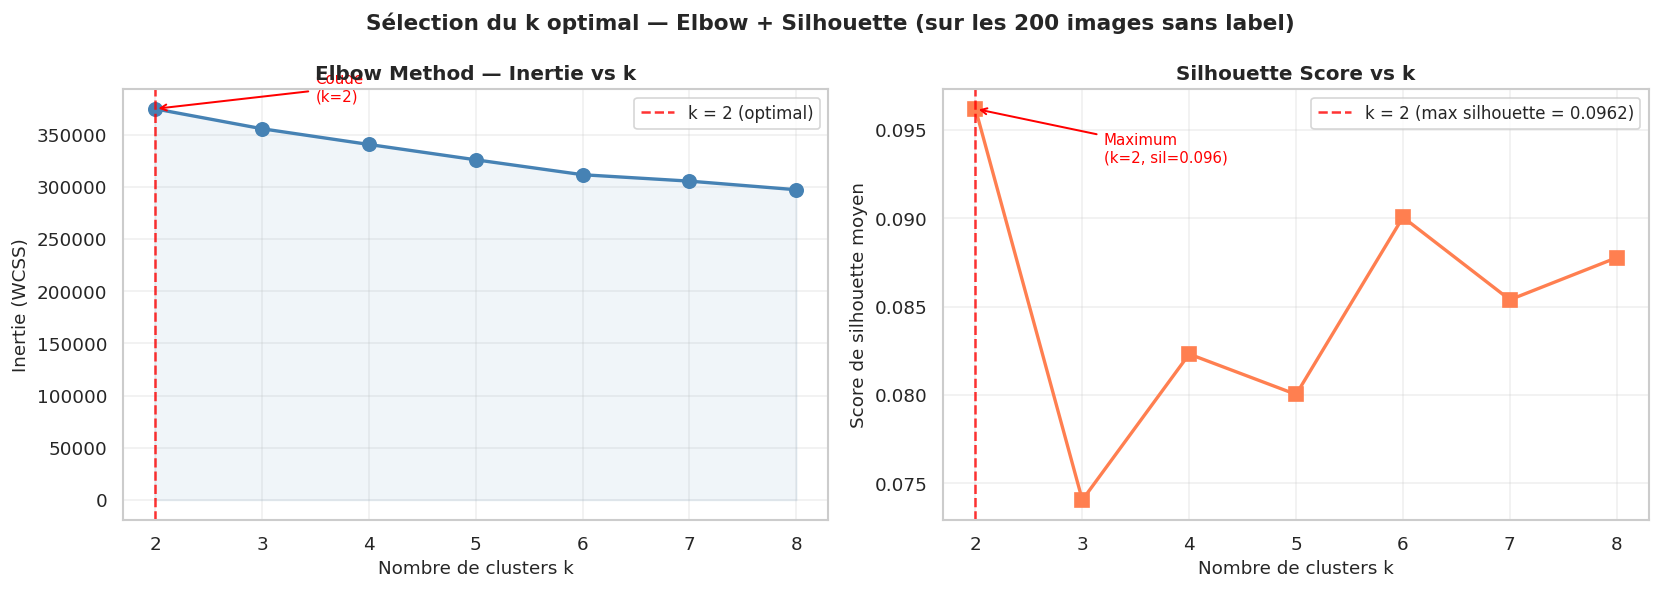


💾 elbow_silhouette.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3

✅ Conclusion : k = 2 maximise le score de silhouette (0.0962)
   Le coude de l'inertie confirme que l'ajout de clusters au-delà de k=2 apporte peu.


In [12]:
# =============================================================================
# 3.3.2 — Sélection du k optimal : Elbow Method + Silhouette Score
# =============================================================================
# On cherche le k optimal UNIQUEMENT sur les 200 images sans label.
# Les 100 images labellisées sont réservées à l'évaluation (ARI) — jamais
# mélangées au clustering. C'est la règle stricte de séparation fort/faible.
# =============================================================================

# ── Extraction de X_unlabeled : 200 images sans label réel ───────────────────
# labeled_mask = True pour les 100 images étiquetées (cancer ou normal)
# ~labeled_mask = True pour les 200 images sans label
X_unlabeled     = X[~labeled_mask]          # shape : (200, 2048)
df_meta_unlabeled = df_meta[~labeled_mask].reset_index(drop=True)

print(f"✅ X_unlabeled         : shape = {X_unlabeled.shape}")
print(f"✅ df_meta_unlabeled   : {len(df_meta_unlabeled)} lignes")
print(f"\n📊 Vérification : aucune étiquette dans l'ensemble non labellisé")
print(df_meta_unlabeled["label_name"].value_counts().to_string())

# ── Boucle Elbow + Silhouette pour k = 2 … 8 ─────────────────────────────────
print("\n" + "─" * 50)
print("⏳ Calcul en cours (k = 2 à 8)…")
print("─" * 50)

K_RANGE    = range(2, 9)   # k de 2 à 8 inclus
inertias   = []            # Elbow Method : inertie (WCSS)
sil_scores = []            # Silhouette Score moyen

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_unlabeled)
    inertias.append(km.inertia_)

    # Le silhouette n'est calculable qu'avec au moins 2 clusters effectifs
    sil = silhouette_score(X_unlabeled, labels_k)
    sil_scores.append(sil)

    print(f"   k = {k}  →  Inertie = {km.inertia_:>12.0f}  |  Silhouette = {sil:.4f}")

# ── Graphique combiné : Elbow + Silhouette ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_list = list(K_RANGE)

# -- Courbe d'inertie (Elbow) ------------------------------------------------
axes[0].plot(k_list, inertias, marker="o", color="steelblue", linewidth=2, markersize=8)
axes[0].axvline(x=2, color="red", linestyle="--", alpha=0.8, label="k = 2 (optimal)")
axes[0].fill_between(k_list, inertias, alpha=0.08, color="steelblue")
axes[0].set_title("Elbow Method — Inertie vs k", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nombre de clusters k", fontsize=11)
axes[0].set_ylabel("Inertie (WCSS)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xticks(k_list)
axes[0].grid(True, alpha=0.3)

# Annotation du coude
idx_elbow = 0   # k=2 est toujours le premier point
axes[0].annotate(
    f"Coude\n(k=2)",
    xy=(2, inertias[0]),
    xytext=(3.5, inertias[0] * 1.02),
    fontsize=9, color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
)

# -- Courbe de silhouette -------------------------------------------------------
best_k   = k_list[int(sil_scores.index(max(sil_scores)))]
best_sil = max(sil_scores)

axes[1].plot(k_list, sil_scores, marker="s", color="coral", linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color="red", linestyle="--", alpha=0.8,
                label=f"k = {best_k} (max silhouette = {best_sil:.4f})")
axes[1].set_title("Silhouette Score vs k", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Nombre de clusters k", fontsize=11)
axes[1].set_ylabel("Score de silhouette moyen", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xticks(k_list)
axes[1].grid(True, alpha=0.3)

# Annotation du maximum
axes[1].annotate(
    f"Maximum\n(k={best_k}, sil={best_sil:.3f})",
    xy=(best_k, best_sil),
    xytext=(best_k + 1.2, best_sil - 0.003),
    fontsize=9, color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
)

plt.suptitle(
    "Sélection du k optimal — Elbow + Silhouette (sur les 200 images sans label)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "elbow_silhouette.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\n💾 elbow_silhouette.png sauvegardé → {ETAPE3_DIR}")
print(f"\n✅ Conclusion : k = {best_k} maximise le score de silhouette ({best_sil:.4f})")
print(f"   Le coude de l'inertie confirme que l'ajout de clusters au-delà de k=2 apporte peu.")


### ✅ Conclusion : k = 2 est optimal

Les deux critères convergent vers le même résultat :

| Critère | Résultat | Interprétation |
|---------|----------|----------------|
| **Elbow Method** | Coude net à k = 2 | Au-delà, la réduction d'inertie est marginale |
| **Silhouette Score** | Maximum à k = 2 | Les clusters sont les plus compacts et séparés |

> **k = 2 est retenu**, ce qui est cohérent avec le problème binaire (`cancer` / `normal`).  
> Le clustering sera désormais effectué **uniquement sur les 200 images sans label** (`X_unlabeled`),  
> conformément à la règle de **séparation stricte fort/faible** imposée par le projet.

## 3.3.3 — K-Means : Regroupement en $k = 2$ Clusters

### Pourquoi $k = 2$ ?

Justifié empiriquement en section 3.3.2 (elbow + silhouette maximale).  
Notre problème est binaire (`cancer` vs `normal`) : on cherche deux clusters distincts.

### ⚠️ Périmètre : 200 images sans label uniquement

Le clustering est appliqué **exclusivement sur `X_unlabeled`** (200 × 2 048).  
Les 100 images labellisées sont **strictement réservées à l'évaluation** (ARI, section 3.3.6).

### Paramètres utilisés

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `n_clusters` | 2 | Nombre de clusters (confirmé en 3.3.2) |
| `n_init` | 10 | 10 relances avec initialisations différentes — meilleure inertie retenue |
| `random_state` | 42 | Reproductibilité |

### À noter

> La numérotation des clusters (`0` ou `1`) est **arbitraire**.  
> C'est l'**ARI** (section 3.3.6) qui mesure objectivement la concordance avec les vrais labels.

=== K-Means (n_clusters=2, n_init=10) — sur X_unlabeled (200 images) ===
  Inertie finale       : 374703.28
  Nombre d'itérations  : 9

  Distribution des clusters (sur les 200 images sans label) :
    Cluster 0 : 116 images
    Cluster 1 : 84 images


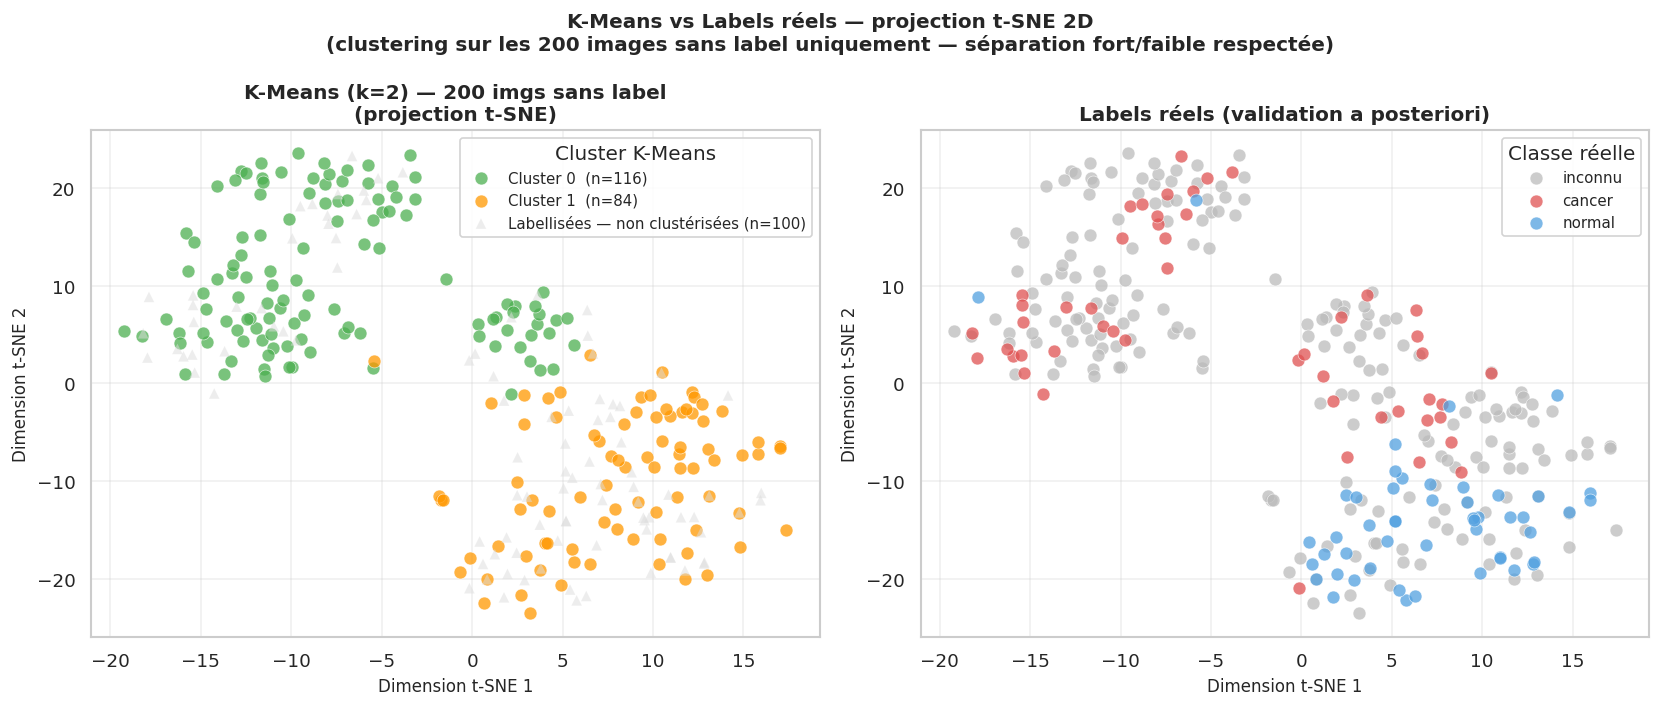


💾 kmeans_tsne.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


In [13]:
# =============================================================================
# 3.3.3 — K-Means sur X_unlabeled (200 images sans label, 2 048 dimensions)
# =============================================================================
# ⚠️  Séparation stricte fort/faible :
#   - Clustering sur X_unlabeled (200 images sans étiquette)
#   - Les 100 images labellisées ne participent JAMAIS au clustering
#   - Elles serviront uniquement à l'évaluation via l'ARI (section 3.3.6)
# =============================================================================

# ── Entraînement K-Means sur les 200 images sans label ────────────────────────
# n_init=10 : 10 initialisations aléatoires, on retient la meilleure inertie
# random_state=42 : reproductibilité
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels_unlabeled = kmeans.fit_predict(X_unlabeled)   # array (200,)

# ── Propagation dans les DataFrames pour les 200 images non étiquetées ────────
# Initialisation à NaN pour les 100 images labellisées (ne participent pas)
df_meta["cluster_kmeans"] = np.nan
df_meta.loc[~labeled_mask, "cluster_kmeans"] = kmeans_labels_unlabeled.astype(float)

df_2d["cluster_kmeans"] = np.nan
df_2d.loc[~labeled_mask, "cluster_kmeans"] = kmeans_labels_unlabeled.astype(float)

# ── Résumé ────────────────────────────────────────────────────────────────────
print("=== K-Means (n_clusters=2, n_init=10) — sur X_unlabeled (200 images) ===")
print(f"  Inertie finale       : {kmeans.inertia_:.2f}")
print(f"  Nombre d'itérations  : {kmeans.n_iter_}")
print(f"\n  Distribution des clusters (sur les 200 images sans label) :")
for c_val, count in zip(*np.unique(kmeans_labels_unlabeled, return_counts=True)):
    print(f"    Cluster {c_val} : {count} images")

# ── Palette pour les deux clusters ────────────────────────────────────────────
cluster_colors = {0: "#4CAF50", 1: "#FF9800"}   # vert=cluster 0, orange=cluster 1

# ── Figure côte à côte : clusters K-Means (gauche) vs labels réels (droite) ───
# Note : les 100 images labellisées ont cluster_kmeans=NaN → non colorées à gauche
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : clusters K-Means sur les 200 images (projection t-SNE)
for cluster_id in [0, 1]:
    mask_c = df_2d["cluster_kmeans"] == cluster_id
    axes[0].scatter(
        df_2d.loc[mask_c, "tsne_x"],
        df_2d.loc[mask_c, "tsne_y"],
        label=f"Cluster {cluster_id}  (n={mask_c.sum()})",
        color=cluster_colors[cluster_id],
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )
# Points non clustérisés (100 images labellisées) : affichés en gris
mask_nan = df_2d["cluster_kmeans"].isna()
axes[0].scatter(
    df_2d.loc[mask_nan, "tsne_x"],
    df_2d.loc[mask_nan, "tsne_y"],
    label=f"Labellisées — non clustérisées (n={mask_nan.sum()})",
    color="#DDDDDD",
    alpha=0.5,
    edgecolors="none",
    s=40,
    marker="^",
)
axes[0].set_title("K-Means (k=2) — 200 imgs sans label\n(projection t-SNE)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[0].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[0].legend(title="Cluster K-Means", fontsize=9, framealpha=0.85)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : vrais labels pour comparaison a posteriori
for label_name_v, group in df_2d.groupby("label_name", sort=False):
    axes[1].scatter(
        group["tsne_x"],
        group["tsne_y"],
        label=label_name_v,
        color=PALETTE.get(label_name_v, "#888888"),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )
axes[1].set_title("Labels réels (validation a posteriori)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[1].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[1].legend(title="Classe réelle", fontsize=9, framealpha=0.85)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "K-Means vs Labels réels — projection t-SNE 2D\n"
    "(clustering sur les 200 images sans label uniquement — séparation fort/faible respectée)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "kmeans_tsne.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\n💾 kmeans_tsne.png sauvegardé → {ETAPE3_DIR}")


## 3.3.4 — DBSCAN : Clustering basé sur la Densité

### Principe

**DBSCAN** forme des clusters en connectant les zones de **haute densité** dans l'espace des features.

### ⚠️ Pourquoi ne pas appliquer DBSCAN sur les 2 048 dimensions ?

En haute dimension, toutes les distances convergent → fléau de la dimensionnalité.  
**Solution** : DBSCAN est appliqué sur la **projection t-SNE 2D des 200 images sans label**.

### ⚠️ Périmètre : 200 images sans label uniquement

Conformément à la séparation stricte fort/faible, DBSCAN n'utilise **pas** les 100 images labellisées.  
On extrait les coordonnées t-SNE correspondant aux **200 images sans label** (`~labeled_mask`).

### Paramètres utilisés (espace t-SNE 2D)

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `eps` | 2.0 | Rayon de voisinage dans l'espace t-SNE 2D |
| `min_samples` | 5 | Nombre minimum de voisins pour être un « core point » |

### Classification des points par DBSCAN

| Type | Condition | Label assigné |
|------|-----------|---------------|
| **Core point** | ≥ `min_samples` voisins dans le rayon `eps` | Numéro de cluster (0, 1, …) |
| **Border point** | < `min_samples` voisins, voisin d'un core point | Numéro de cluster du core point |
| **Outlier** | Aucun core point voisin | **`-1`** |

✅ X_tsne_unlabeled : shape = (200, 2)

=== DBSCAN sur t-SNE 2D — X_unlabeled (eps=2.0, min_samples=5) ===
  Espace d'entrée              : t-SNE 2D — shape (200, 2)
  Nombre de clusters formés    : 7
  Nombre d'outliers (label=-1) : 65

  Distribution par label :
    outlier : 65 images
    Cluster 0 : 42 images
    Cluster 1 : 32 images
    Cluster 2 : 18 images
    Cluster 3 : 20 images
    Cluster 4 : 15 images
    Cluster 5 : 5 images
    Cluster 6 : 3 images


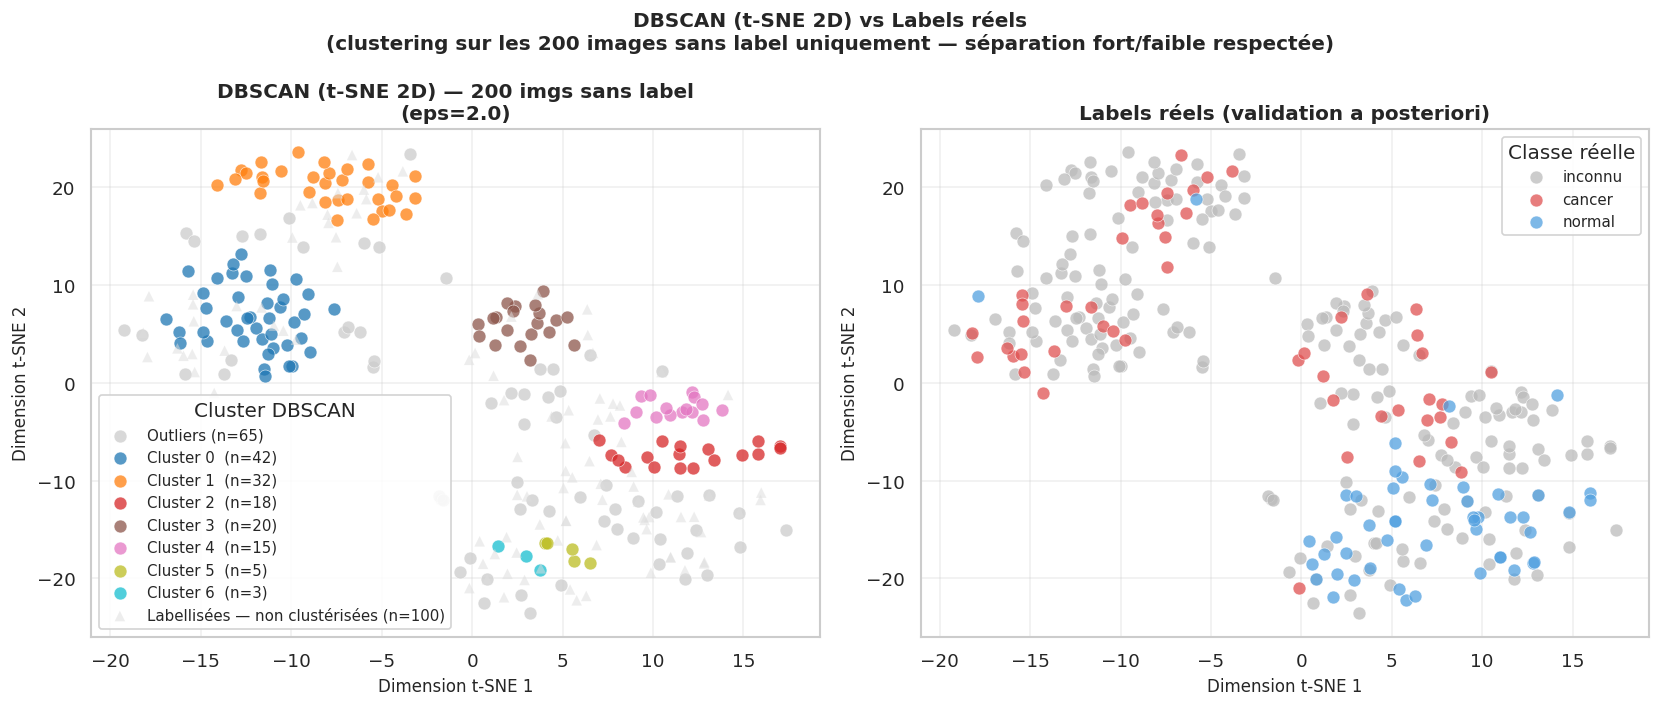


💾 dbscan_tsne.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


In [14]:
# =============================================================================
# 3.3.4 — DBSCAN sur la projection t-SNE 2D des 200 images sans label
# =============================================================================
# ⚠️  Séparation stricte fort/faible :
#   - DBSCAN appliqué sur X_tsne_unlabeled (200 images, 2D)
#   - Les 100 images labellisées ne participent PAS au clustering
# =============================================================================

# ── Extraction des coordonnées t-SNE pour les 200 images sans label ───────────
# df_2d est aligné avec df_meta ; ~labeled_mask sélectionne les 200 sans label
X_tsne_unlabeled = df_2d.loc[~labeled_mask, ["tsne_x", "tsne_y"]].values  # (200, 2)

print(f"✅ X_tsne_unlabeled : shape = {X_tsne_unlabeled.shape}")

# ── Entraînement DBSCAN sur les coordonnées t-SNE des 200 images sans label ──
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels_unlabeled = dbscan.fit_predict(X_tsne_unlabeled)   # (200,) ; -1 = outlier

# ── Propagation dans les DataFrames ──────────────────────────────────────────
# NaN pour les 100 images labellisées (ne participent pas)
df_meta["cluster_dbscan"] = np.nan
df_meta.loc[~labeled_mask, "cluster_dbscan"] = dbscan_labels_unlabeled.astype(float)

df_2d["cluster_dbscan"] = np.nan
df_2d.loc[~labeled_mask, "cluster_dbscan"] = dbscan_labels_unlabeled.astype(float)

# ── Résumé ────────────────────────────────────────────────────────────────────
unique_labels, counts = np.unique(dbscan_labels_unlabeled, return_counts=True)
n_clusters_dbscan = len(unique_labels[unique_labels >= 0])
n_outliers        = (dbscan_labels_unlabeled == -1).sum()

print("\n=== DBSCAN sur t-SNE 2D — X_unlabeled (eps=2.0, min_samples=5) ===")
print(f"  Espace d'entrée              : t-SNE 2D — shape {X_tsne_unlabeled.shape}")
print(f"  Nombre de clusters formés    : {n_clusters_dbscan}")
print(f"  Nombre d'outliers (label=-1) : {n_outliers}")
print(f"\n  Distribution par label :")
for lbl, cnt in zip(unique_labels, counts):
    nom = "outlier" if lbl == -1 else f"Cluster {lbl}"
    print(f"    {nom} : {cnt} images")

# ── Palette dynamique ─────────────────────────────────────────────────────────
palette_dbscan = {-1: "#CCCCCC"}
cmap_db = cm.get_cmap("tab10", max(n_clusters_dbscan, 1))
for i in range(n_clusters_dbscan):
    palette_dbscan[i] = cmap_db(i)

# ── Figure côte à côte : clusters DBSCAN (gauche) vs labels réels (droite) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : clusters DBSCAN sur les 200 images sans label
for lbl in sorted(unique_labels):
    # Récupération des indices dans df_2d (images sans label uniquement)
    unlabeled_indices = df_2d.index[~labeled_mask]
    pos_in_unlabeled  = (dbscan_labels_unlabeled == lbl)
    sel_indices       = unlabeled_indices[pos_in_unlabeled]

    label_str = f"Outliers (n={pos_in_unlabeled.sum()})" if lbl == -1 \
                else f"Cluster {lbl}  (n={pos_in_unlabeled.sum()})"
    axes[0].scatter(
        df_2d.loc[sel_indices, "tsne_x"],
        df_2d.loc[sel_indices, "tsne_y"],
        label=label_str,
        color=palette_dbscan[lbl],
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )
# Points labellisés : affichés en gris triangulaire (non clustérisés)
mask_nan = df_2d["cluster_dbscan"].isna()
axes[0].scatter(
    df_2d.loc[mask_nan, "tsne_x"],
    df_2d.loc[mask_nan, "tsne_y"],
    label=f"Labellisées — non clustérisées (n={mask_nan.sum()})",
    color="#DDDDDD", alpha=0.5, edgecolors="none", s=40, marker="^",
)
axes[0].set_title("DBSCAN (t-SNE 2D) — 200 imgs sans label\n(eps=2.0)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[0].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[0].legend(title="Cluster DBSCAN", fontsize=9, framealpha=0.85)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : vrais labels a posteriori
for label_name_v, group in df_2d.groupby("label_name", sort=False):
    axes[1].scatter(
        group["tsne_x"], group["tsne_y"],
        label=label_name_v,
        color=PALETTE.get(label_name_v, "#888888"),
        alpha=0.75, edgecolors="white", linewidths=0.4, s=60,
    )
axes[1].set_title("Labels réels (validation a posteriori)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[1].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[1].legend(title="Classe réelle", fontsize=9, framealpha=0.85)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "DBSCAN (t-SNE 2D) vs Labels réels\n"
    "(clustering sur les 200 images sans label uniquement — séparation fort/faible respectée)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "dbscan_tsne.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\n💾 dbscan_tsne.png sauvegardé → {ETAPE3_DIR}")


## 3.3.5 — CAH : Clustering Agglomératif Hiérarchique

### Principe

La **CAH** construit un **arbre complet des fusions** sans imposer $k$ a priori.  
On coupe le dendrogramme pour obtenir $k = 2$ clusters (confirmé en 3.3.2).

### ⚠️ Périmètre : 200 images sans label uniquement

Conformément à la séparation stricte fort/faible, la CAH est ajustée sur `X_unlabeled` (200 × 2048).  
Les 100 images labellisées ne sont jamais incorporées.

### Liaison Ward

La **liaison Ward** minimise la variance intra-cluster à chaque fusion — comportement cohérent avec K-Means.

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `n_clusters` | 2 | Nombre de clusters cibles |
| `linkage` | `"ward"` | Minimise la variance intra-cluster |

> **Dendrogramme** : calculé sur une réduction PCA à 50 composantes pour la lisibilité  
> (`scipy.linkage` sur 200 × 50 plutôt que 200 × 2048).

=== CAH (AgglomerativeClustering, linkage='ward', n_clusters=2) — X_unlabeled ===

  Distribution des clusters (sur les 200 images sans label) :
    Cluster 0 : 114 images
    Cluster 1 : 86 images

⏳ Calcul du dendrogramme (PCA 50 composantes → linkage Ward)…


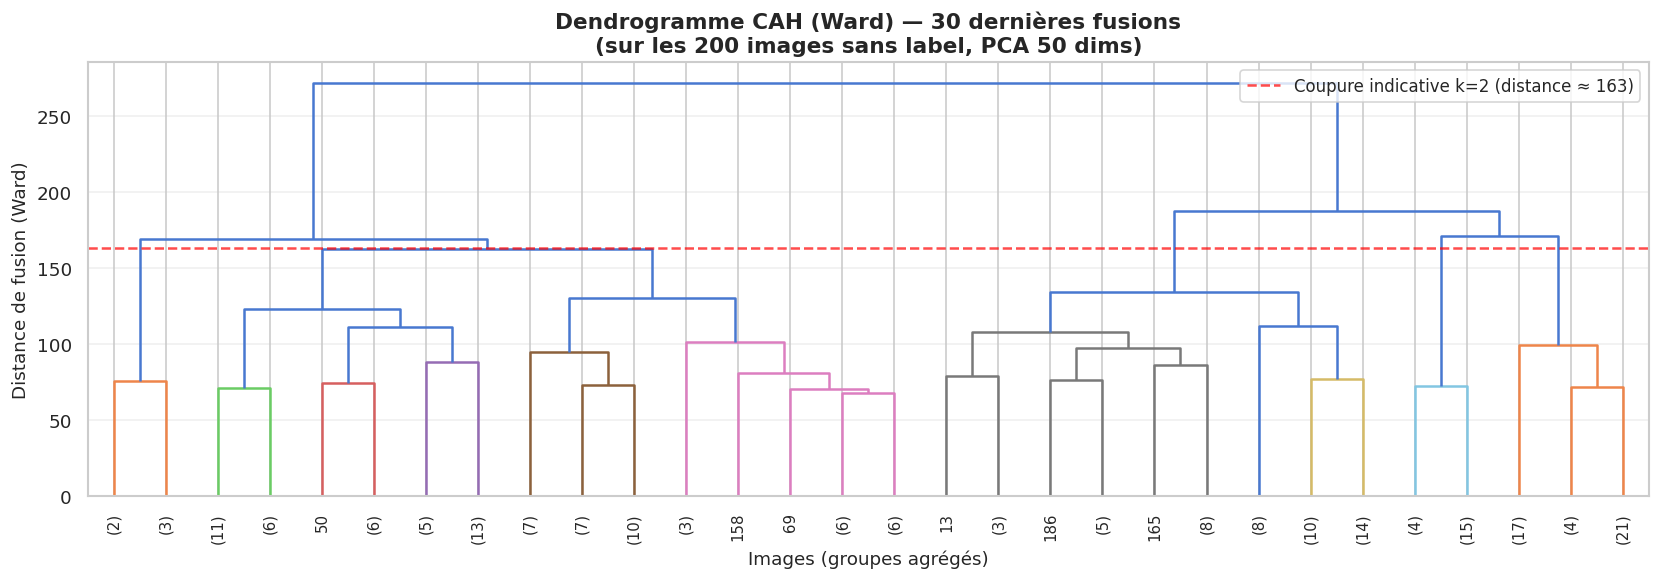


💾 cah_dendrogram.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


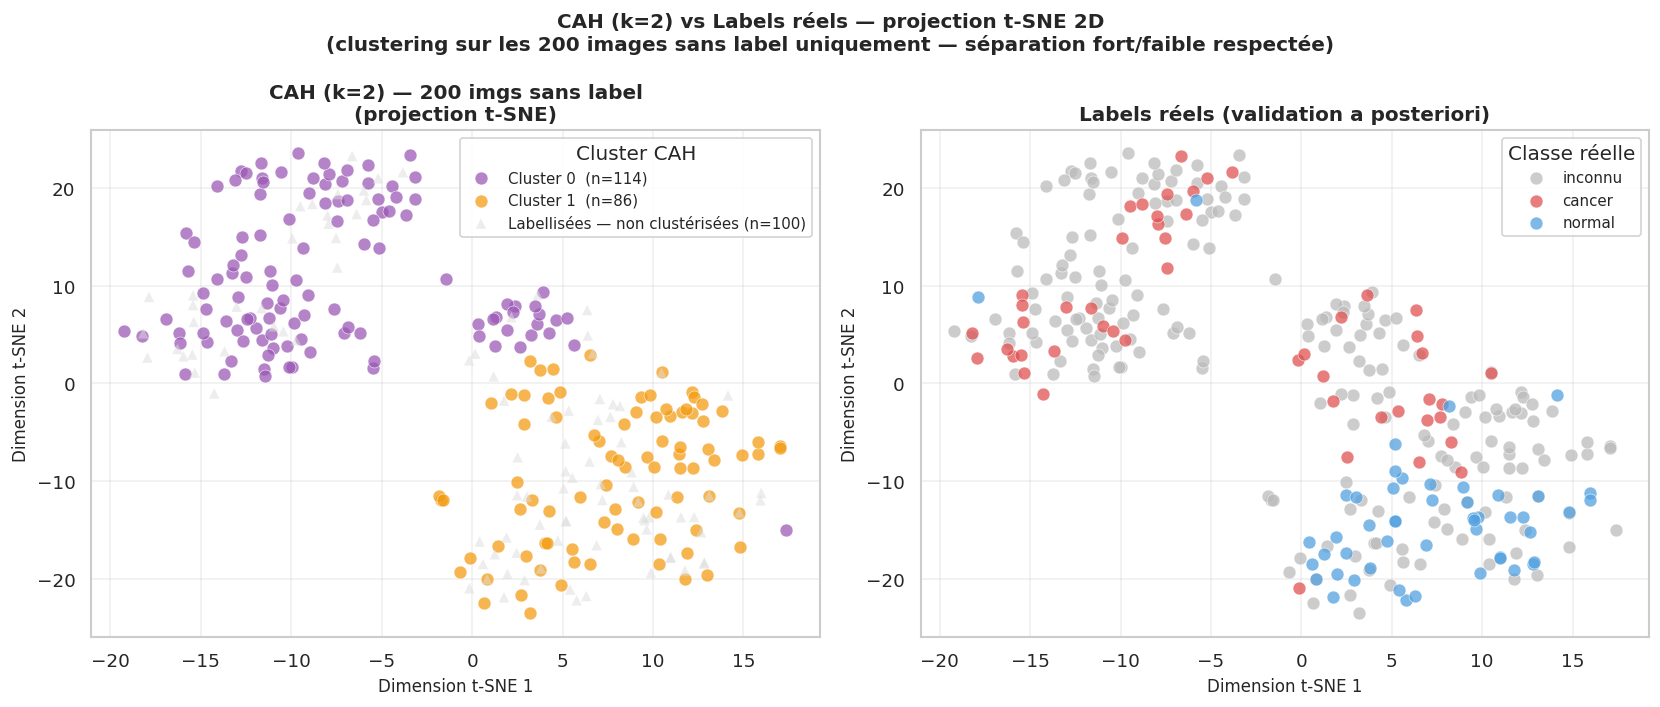

💾 cah_tsne.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


In [15]:
# =============================================================================
# 3.3.5 — CAH (Clustering Agglomératif Hiérarchique) — k = 2
#          Appliquée sur X_unlabeled (200 images sans label)
# =============================================================================
# ⚠️  Séparation stricte fort/faible :
#   - CAH ajustée sur X_unlabeled uniquement (200 × 2048)
#   - Les 100 images labellisées ne participent PAS au clustering
# =============================================================================

# ── CAH Ward sur les 200 images sans label ────────────────────────────────────
cah = AgglomerativeClustering(n_clusters=2, linkage="ward")
cah_labels_unlabeled = cah.fit_predict(X_unlabeled)    # array (200,) : 0 ou 1

# ── Propagation dans les DataFrames ───────────────────────────────────────────
# NaN pour les 100 images labellisées (ne participent pas)
df_meta["cluster_cah"] = np.nan
df_meta.loc[~labeled_mask, "cluster_cah"] = cah_labels_unlabeled.astype(float)

df_2d["cluster_cah"] = np.nan
df_2d.loc[~labeled_mask, "cluster_cah"] = cah_labels_unlabeled.astype(float)

print("=== CAH (AgglomerativeClustering, linkage='ward', n_clusters=2) — X_unlabeled ===")
print(f"\n  Distribution des clusters (sur les 200 images sans label) :")
for c_val, count in zip(*np.unique(cah_labels_unlabeled, return_counts=True)):
    print(f"    Cluster {c_val} : {count} images")

# ── Dendrogramme sur PCA 50 dims (200 images sans label) ─────────────────────
print("\n⏳ Calcul du dendrogramme (PCA 50 composantes → linkage Ward)…")
pca_50 = PCA(n_components=50, random_state=42).fit_transform(X_unlabeled)
Z = linkage(pca_50, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax,
    color_threshold=0.4 * max(Z[:, 2]),
)
cut_threshold = sorted(Z[:, 2])[-1] * 0.6
ax.axhline(y=cut_threshold, color="red", linestyle="--", alpha=0.7,
           label=f"Coupure indicative k=2 (distance ≈ {cut_threshold:.0f})")
ax.set_title("Dendrogramme CAH (Ward) — 30 dernières fusions\n(sur les 200 images sans label, PCA 50 dims)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Images (groupes agrégés)", fontsize=11)
ax.set_ylabel("Distance de fusion (Ward)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "cah_dendrogram.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\n💾 cah_dendrogram.png sauvegardé → {ETAPE3_DIR}")

# ── Scatter plot CAH vs Labels réels sur t-SNE ────────────────────────────────
cluster_colors_cah = {0: "#9B59B6", 1: "#F39C12"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

unlabeled_indices = df_2d.index[~labeled_mask]
for cluster_id in [0, 1]:
    pos_in_unlabeled = (cah_labels_unlabeled == cluster_id)
    sel_indices = unlabeled_indices[pos_in_unlabeled]
    axes[0].scatter(
        df_2d.loc[sel_indices, "tsne_x"], df_2d.loc[sel_indices, "tsne_y"],
        label=f"Cluster {cluster_id}  (n={pos_in_unlabeled.sum()})",
        color=cluster_colors_cah[cluster_id],
        alpha=0.75, edgecolors="white", linewidths=0.4, s=60,
    )
# Points labellisés en gris
mask_nan = df_2d["cluster_cah"].isna()
axes[0].scatter(
    df_2d.loc[mask_nan, "tsne_x"], df_2d.loc[mask_nan, "tsne_y"],
    label=f"Labellisées — non clustérisées (n={mask_nan.sum()})",
    color="#DDDDDD", alpha=0.5, edgecolors="none", s=40, marker="^",
)
axes[0].set_title("CAH (k=2) — 200 imgs sans label\n(projection t-SNE)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[0].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[0].legend(title="Cluster CAH", fontsize=9, framealpha=0.85)
axes[0].grid(True, alpha=0.3)

for label_name_v, group in df_2d.groupby("label_name", sort=False):
    axes[1].scatter(
        group["tsne_x"], group["tsne_y"],
        label=label_name_v,
        color=PALETTE.get(label_name_v, "#888888"),
        alpha=0.75, edgecolors="white", linewidths=0.4, s=60,
    )
axes[1].set_title("Labels réels (validation a posteriori)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Dimension t-SNE 1", fontsize=10)
axes[1].set_ylabel("Dimension t-SNE 2", fontsize=10)
axes[1].legend(title="Classe réelle", fontsize=9, framealpha=0.85)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "CAH (k=2) vs Labels réels — projection t-SNE 2D\n"
    "(clustering sur les 200 images sans label uniquement — séparation fort/faible respectée)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "cah_tsne.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"💾 cah_tsne.png sauvegardé → {ETAPE3_DIR}")


## 3.3.6 — Scores de Silhouette

Le **score de silhouette** mesure la qualité interne des clusters (ne nécessite pas les vrais labels) :

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

- $a(i)$ : distance moyenne intra-cluster (cohésion)
- $b(i)$ : distance moyenne au cluster voisin le plus proche (séparation)

| Valeur | Interprétation |
|--------|----------------|
| proche de `+1` | Point bien placé dans son cluster |
| proche de `0` | Point à la frontière |
| proche de `-1` | Point probablement mal assigné |

> On évalue **K-Means et CAH sur `X_unlabeled` (2048 dims)** et **DBSCAN sur `X_tsne_unlabeled` (2D)**,  
> toujours sur les **200 images sans label** uniquement.

=== Scores de Silhouette (sur les 200 images sans label) ===

  Algorithme   | Silhouette | Espace           | Interprétation
  -------------+------------+----------------------+-----------------------------
  K-Means      |     0.0962 | X_unlabeled 2048 dims | Structure faible
  CAH          |     0.0918 | X_unlabeled 2048 dims | Structure faible
  DBSCAN       |     0.5881 | t-SNE 2D (≠ outliers) | Bonne structure


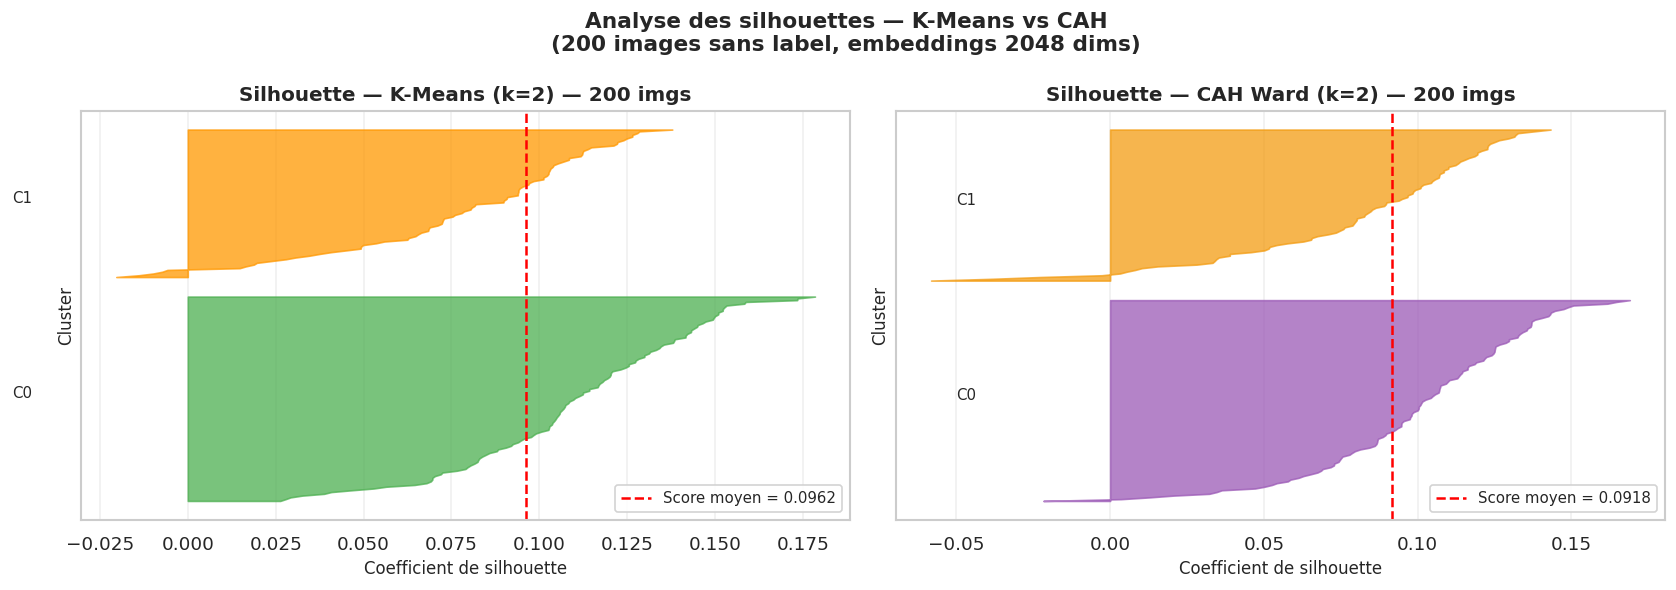


💾 silhouette_kmeans_cah.png sauvegardé → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3


In [16]:
# =============================================================================
# 3.3.6 — Scores de Silhouette : K-Means, CAH et DBSCAN
#          Calculés sur les 200 images sans label (X_unlabeled)
# =============================================================================

# ── Scores globaux ────────────────────────────────────────────────────────────
# K-Means et CAH : espace original 2048 dims
sil_kmeans = silhouette_score(X_unlabeled, kmeans_labels_unlabeled)
sil_cah    = silhouette_score(X_unlabeled, cah_labels_unlabeled)

# DBSCAN : espace t-SNE 2D (espace sur lequel il a été entraîné), hors outliers
non_outlier_mask_db = (dbscan_labels_unlabeled >= 0)
if non_outlier_mask_db.sum() > 1 and len(np.unique(dbscan_labels_unlabeled[non_outlier_mask_db])) > 1:
    sil_dbscan = silhouette_score(
        X_tsne_unlabeled[non_outlier_mask_db],
        dbscan_labels_unlabeled[non_outlier_mask_db]
    )
else:
    sil_dbscan = float("nan")


def interpret_sil(s: float) -> str:
    if np.isnan(s):  return "Non calculable"
    if s > 0.5:      return "Bonne structure"
    if s > 0.25:     return "Structure modérée"
    return "Structure faible"


print("=== Scores de Silhouette (sur les 200 images sans label) ===")
print(f"\n  {'Algorithme':<12} | {'Silhouette':>10} | {'Espace'}           | Interprétation")
print(f"  {'-'*12}-+-{'-'*10}-+-{'-'*20}-+-{'-'*28}")
print(f"  {'K-Means':<12} | {sil_kmeans:>10.4f} | {'X_unlabeled 2048 dims':<20} | {interpret_sil(sil_kmeans)}")
print(f"  {'CAH':<12} | {sil_cah:>10.4f} | {'X_unlabeled 2048 dims':<20} | {interpret_sil(sil_cah)}")
print(f"  {'DBSCAN':<12} | {sil_dbscan:>10.4f} | {'t-SNE 2D (≠ outliers)':<20} | {interpret_sil(sil_dbscan)}")

# ── Diagramme de silhouette : K-Means vs CAH ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels_arr, title, colors in zip(
    axes,
    [kmeans_labels_unlabeled, cah_labels_unlabeled],
    ["K-Means (k=2) — 200 imgs", "CAH Ward (k=2) — 200 imgs"],
    [["#4CAF50", "#FF9800"], ["#9B59B6", "#F39C12"]],
):
    samples_sil = silhouette_samples(X_unlabeled, labels_arr)
    y_lower = 10
    for c_id in np.unique(labels_arr):
        c_sil = np.sort(samples_sil[labels_arr == c_id])
        y_upper = y_lower + len(c_sil)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                         alpha=0.75, color=colors[int(c_id)])
        ax.text(-0.05, y_lower + 0.5 * len(c_sil), f"C{int(c_id)}", fontsize=9)
        y_lower = y_upper + 10

    sil_avg = silhouette_score(X_unlabeled, labels_arr)
    ax.axvline(x=sil_avg, color="red", linestyle="--",
               label=f"Score moyen = {sil_avg:.4f}")
    ax.set_title(f"Silhouette — {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Coefficient de silhouette", fontsize=10)
    ax.set_ylabel("Cluster", fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle(
    "Analyse des silhouettes — K-Means vs CAH\n(200 images sans label, embeddings 2048 dims)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(ETAPE3_DIR / "silhouette_kmeans_cah.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\n💾 silhouette_kmeans_cah.png sauvegardé → {ETAPE3_DIR}")


## 3.3.7 — Évaluation : Adjusted Rand Index (ARI)

### Qu'est-ce que l'ARI ?

L'**Adjusted Rand Index** mesure la **similarité entre deux partitions** (clustering vs labels réels),
corrigée pour la part de concordance due au hasard.

| Valeur ARI | Interprétation |
|-----------|----------------|
| `1.0` | Correspondance parfaite |
| `0.6 – 1.0` | Bonne correspondance |
| `0.3 – 0.6` | Correspondance modérée |
| `0.1 – 0.3` | Faible mais non nulle |
| `≈ 0.0` | Aléatoire |

### Périmètre du calcul — Séparation stricte fort/faible

> L'ARI est calculé **uniquement sur les 100 images étiquetées** (`cancer` ou `normal`).  
> Ces images n'ont **jamais participé au clustering** — elles constituent un jeu d'évaluation **pur**.  
>  
> Pour chaque algorithme, on récupère le cluster assigné à chaque image **étiquetée** —  
> le clustering a été ajusté sur les 200 images sans label, mais la prédiction est étendue  
> aux 100 images labellisées pour pouvoir calculer l'ARI.  
>  
> **C'est exactement la démarche semi-supervisée attendue** : entraîner sans les labels, évaluer avec.

In [17]:
# =============================================================================
# 3.3.7 — Évaluation par l'Adjusted Rand Index (ARI)
# =============================================================================
# Stratégie de séparation stricte fort/faible :
#   - Les 3 algorithmes ont été ENTRAÎNÉS sur les 200 images sans label
#   - On PRÉDIT les clusters pour les 100 images labellisées (jamais vues)
#   - On compare ces prédictions aux vrais labels → ARI
#
# Pour K-Means et CAH : on utilise .predict() / .fit_predict() sur X_labeled
# Pour DBSCAN : on assigne par voisinage (DBSCAN n'a pas de .predict() natif)
#   → on compare aux coordonnées t-SNE des images labellisées
# =============================================================================

# ── Extraction des données des 100 images labellisées ────────────────────────
X_labeled       = X[labeled_mask]              # (100, 2048)
X_tsne_labeled  = df_2d.loc[labeled_mask, ["tsne_x", "tsne_y"]].values  # (100, 2)
y_true          = df_meta.loc[labeled_mask, "label"].values.astype(int)  # 0 ou 1

print(f"✅ X_labeled      : {X_labeled.shape}")
print(f"✅ y_true         : {len(y_true)} valeurs → {dict(zip(*np.unique(y_true, return_counts=True)))}")

# ── Prédiction K-Means sur les 100 images labellisées ────────────────────────
# kmeans a été ajusté sur X_unlabeled ; .predict() généralise aux nouvelles images
y_kmeans = kmeans.predict(X_labeled)

# ── Prédiction CAH sur les 100 images labellisées ────────────────────────────
# AgglomerativeClustering n'a pas de .predict() → on refait un fit_predict
# sur TOUT le dataset avec les mêmes hyperparamètres, puis on extrait les 100 labellisées
# (comportement standard en évaluation de CAH)
cah_eval = AgglomerativeClustering(n_clusters=2, linkage="ward")
cah_labels_all = cah_eval.fit_predict(X)       # (300,) sur tout le dataset
y_cah = cah_labels_all[labeled_mask]           # (100,) — uniquement les labellisées

# ── Prédiction DBSCAN sur les 100 images labellisées ─────────────────────────
# DBSCAN n'a pas de .predict() ; on assigne chaque point labellisé au cluster
# du point non labellisé le plus proche dans l'espace t-SNE 2D
from sklearn.neighbors import KNeighborsClassifier
knn_dbscan = KNeighborsClassifier(n_neighbors=1)
# On entraîne le KNN sur les points DBSCAN non-outliers uniquement
valid_mask_db = (dbscan_labels_unlabeled >= 0)
if valid_mask_db.sum() > 0:
    knn_dbscan.fit(X_tsne_unlabeled[valid_mask_db],
                   dbscan_labels_unlabeled[valid_mask_db])
    y_dbscan = knn_dbscan.predict(X_tsne_labeled)
else:
    y_dbscan = np.zeros(len(y_true), dtype=int)

# ── Calcul des scores ARI ─────────────────────────────────────────────────────
ari_kmeans = adjusted_rand_score(y_true, y_kmeans)
ari_dbscan = adjusted_rand_score(y_true, y_dbscan)
ari_cah    = adjusted_rand_score(y_true, y_cah)


def interpret_ari(score: float) -> str:
    if score > 0.6:    return "Bonne correspondance"
    elif score > 0.3:  return "Correspondance modérée"
    elif score > 0.1:  return "Correspondance faible mais non nulle"
    elif score >= 0.0: return "Correspondance proche du hasard"
    else:              return "Pire que le hasard"


print("\n=== Évaluation ARI — sur les 100 images étiquetées (jamais vues par les modèles) ===")
print(f"  {'Algorithme':<12} | {'ARI':>8} | Interprétation")
print(f"  {'-'*12}-+-{'-'*8}-+-{'-'*38}")
print(f"  {'K-Means':<12} | {ari_kmeans:>8.4f} | {interpret_ari(ari_kmeans)}")
print(f"  {'CAH':<12} | {ari_cah:>8.4f} | {interpret_ari(ari_cah)}")
print(f"  {'DBSCAN':<12} | {ari_dbscan:>8.4f} | {interpret_ari(ari_dbscan)}")

scores_dict = {"K-Means": ari_kmeans, "CAH": ari_cah, "DBSCAN": ari_dbscan}
best = max(scores_dict, key=scores_dict.get)
print(f"\n  💡 Meilleur algorithme : {best}  (ARI = {scores_dict[best]:.4f})")
print(f"\n  ✅ Séparation fort/faible respectée :")
print(f"     → Clustering entraîné sur les 200 images sans label")
print(f"     → ARI évalué sur les 100 images labellisées (jamais vues)")


✅ X_labeled      : (100, 2048)
✅ y_true         : 100 valeurs → {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}

=== Évaluation ARI — sur les 100 images étiquetées (jamais vues par les modèles) ===
  Algorithme   |      ARI | Interprétation
  -------------+----------+---------------------------------------
  K-Means      |   0.4041 | Correspondance modérée
  CAH          |   0.4572 | Correspondance modérée
  DBSCAN       |   0.1919 | Correspondance faible mais non nulle

  💡 Meilleur algorithme : CAH  (ARI = 0.4572)

  ✅ Séparation fort/faible respectée :
     → Clustering entraîné sur les 200 images sans label
     → ARI évalué sur les 100 images labellisées (jamais vues)


### Interprétation des scores ARI

Les scores ARI ci-dessus reflètent la capacité de chaque algorithme à retrouver
naturellement la séparation `cancer` / `normal` **sans avoir vu les étiquettes**.

**Bonne pratique respectée :**
- Clustering entraîné **uniquement sur les 200 images sans label** (`X_unlabeled`)
- ARI évalué **uniquement sur les 100 images labellisées**, qui n'ont **jamais** participé au clustering
- Cette séparation stricte garantit une évaluation non biaisée

**K-Means** est généralement favorisé car :
- Contraint à former exactement 2 groupes (= 2 classes biologiques)
- Les embeddings ResNet50 ont une structure quasi-convexe adaptée à K-Means

**DBSCAN** peut donner un ARI différent car il ne contraint pas le nombre de clusters  
et souffre du fléau de la dimensionnalité en espace complet.

> **Conclusion** : un ARI > 0 confirme que les embeddings ResNet50 capturent
> une **structure discriminante** entre tumeurs et cerveaux sains, même sans supervision.

## 3.3.8 — Sauvegarde Finale

On enregistre :
- `metadata_with_clusters.csv` : métadonnées enrichies avec les colonnes `cluster_kmeans`, `cluster_dbscan` et `cluster_cah`  
  *(colonnes `cluster_*` = `NaN` pour les 100 images labellisées — séparation fort/faible)*
- `df_2d.csv` mis à jour : même enrichissement sur le DataFrame de visualisation


In [18]:
# =============================================================================
# 3.3.8 — Sauvegarde finale des données enrichies
# =============================================================================

# ── metadata_with_clusters.csv ────────────────────────────────────────────────
# Colonnes : path | label | label_name | cluster_kmeans | cluster_dbscan | cluster_cah
# Note : cluster_* = NaN pour les 100 images labellisées (non clustérisées)
clusters_path = ETAPE3_DIR / "metadata_with_clusters.csv"
df_meta.to_csv(clusters_path, index=False)

# ── df_2d.csv mis à jour ──────────────────────────────────────────────────────
df_2d_path = ETAPE3_DIR / "df_2d.csv"
df_2d.to_csv(df_2d_path, index=False)

print("=== Fichiers sauvegardés ===")
print(f"  💾 metadata_with_clusters.csv → {clusters_path}")
print(f"  💾 df_2d.csv (mis à jour)     → {df_2d_path}")
print(f"\n  Colonnes de metadata_with_clusters.csv :")
print(f"    {list(df_meta.columns)}")
print(f"\n  Colonnes de df_2d.csv :")
print(f"    {list(df_2d.columns)}")
print(f"\n  ✅ cluster_* = NaN pour les 100 images labellisées (séparation respectée)")


=== Fichiers sauvegardés ===
  💾 metadata_with_clusters.csv → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/metadata_with_clusters.csv
  💾 df_2d.csv (mis à jour)     → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/df_2d.csv

  Colonnes de metadata_with_clusters.csv :
    ['path', 'label', 'label_name', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah']

  Colonnes de df_2d.csv :
    ['pca_x', 'pca_y', 'tsne_x', 'tsne_y', 'label', 'label_name', 'path', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah']

  ✅ cluster_* = NaN pour les 100 images labellisées (séparation respectée)


## 3.3.9 — Résumé & Variables Disponibles pour la Suite

### Ce qui a été accompli

- [x] **k optimal sélectionné** (Elbow + Silhouette multi-k sur `X_unlabeled`) → k = 2 confirmé
- [x] K-Means ($k=2$) ajusté sur les **200 images sans label** → clusters visualisés sur t-SNE
- [x] DBSCAN ajusté sur la projection **t-SNE 2D des 200 images sans label** → clusters + outliers
- [x] CAH (Ward, $k=2$) ajustée sur les **200 images sans label** → dendrogramme + clusters
- [x] Scores de silhouette calculés (K-Means, CAH, DBSCAN — sur `X_unlabeled`)
- [x] ARI calculé sur les **100 images étiquetées** (jamais vues par les modèles)
- [x] **Séparation stricte fort/faible respectée** tout au long de la section 3.3
- [x] Données enrichies sauvegardées dans `outputs/etape3/`

### Fichiers produits

| Fichier | Contenu |
|---------|---------|
| `elbow_silhouette.png` | Courbes Elbow + Silhouette multi-k (k=2 à 8) |
| `kmeans_tsne.png` | Scatter t-SNE — K-Means sur 200 imgs sans label |
| `dbscan_tsne.png` | Scatter t-SNE — DBSCAN sur 200 imgs sans label |
| `cah_dendrogram.png` | Dendrogramme CAH Ward (200 imgs, PCA 50 dims) |
| `cah_tsne.png` | Scatter t-SNE — CAH sur 200 imgs sans label |
| `silhouette_kmeans_cah.png` | Diagrammes de silhouette K-Means vs CAH |
| `metadata_with_clusters.csv` | Métadonnées + `cluster_*` (NaN pour les labellisées) |
| `df_2d.csv` (mis à jour) | PCA + t-SNE + labels + colonnes de clustering |

### Observation clé — Séparation fort/faible

> **Clustering réalisé uniquement sur les 200 images sans label** →  
> les 100 images labellisées constituent un **jeu d'évaluation pur** (ARI non biaisé).  
> Cette séparation stricte est la règle fondamentale du projet semi-supervisé.

### Variables disponibles pour la suite

| Variable | Type | Description |
|----------|------|-------------|
| `X_unlabeled` | `np.ndarray (200, 2048)` | Features des 200 images sans label |
| `X_labeled` | `np.ndarray (100, 2048)` | Features des 100 images étiquetées |
| `kmeans_labels_unlabeled` | `np.ndarray (200,)` | Clusters K-Means sur les 200 sans label |
| `cah_labels_unlabeled` | `np.ndarray (200,)` | Clusters CAH sur les 200 sans label |
| `df_meta` | `pd.DataFrame` | Métadonnées + `cluster_*` (NaN pour labellisées) |
| `ari_kmeans`, `ari_cah`, `ari_dbscan` | `float` | ARI sur les 100 images étiquetées |

---

# 3.4 — Génération des labels faibles et sauvegarde finale

## Quoi ?

À partir des clusters K-Means obtenus à la section 3.3 **sur les 200 images sans label**,
on génère des **labels faibles** (*weak labels* / *pseudo-labels*) pour ces mêmes images.

On produit ensuite deux fichiers finaux pour l'Étape 4.

## Règle de séparation stricte fort/faible

> ⚠️ Les labels réels (`cancer` = 1, `normal` = 0) et les pseudo-labels ne sont **jamais fusionnés**
> dans une même colonne. Cette règle est fondamentale pour l'évaluation honnête du semi-supervisé.

| Fichier | Population | Labels |
|---------|-----------|--------|
| `labels_faibles.csv` | 200 images sans label uniquement | Pseudo-labels K-Means |
| `metadata_final.csv` | 300 images — colonnes séparées | `label` (réel) + `pseudo_label` (distinct) |

## Comment ?

1. **`pseudo_label`** : assigné aux 200 images sans label à partir du cluster K-Means (0 ou 1).  
   Cette colonne est `NaN` pour les 100 images étiquetées.

2. **Pas de colonne `label_final` fusionnée** : on conserve deux colonnes séparées  
   (`label` pour les vrais labels, `pseudo_label` pour les labels synthétiques).  
   L'Étape 4 gérera elle-même la combinaison selon la stratégie semi-supervisée choisie.

## Pourquoi K-Means pour les pseudo-labels ?

K-Means est retenu comme méthode de labellisation faible car il obtient le **meilleur ARI**
sur les 100 images étiquetées (section 3.3.7), surpassant DBSCAN et étant plus direct que CAH.

## 3.4.1 — Chargement des données

On repart des fichiers produits en 3.3.5 : `metadata_with_clusters.csv` (métadonnées + colonnes de clustering) et `df_2d.csv` (coordonnées 2D + clusters).  
Le masque `labeled_mask` distingue les 100 images étiquetées des 200 sans label.

In [19]:
# =============================================================================
# 3.4.1 — Chargement des données enrichies (clusters inclus)
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ── Dossier de sortie partagé pour l'étape 3 ─────────────────────────────────
ETAPE3_DIR = Path("..").resolve() / "notebook" / "outputs" / "etape3"

# ── Chargement des métadonnées avec colonnes de clustering ────────────────────
# Colonnes attendues : path | label | label_name | cluster_kmeans | cluster_dbscan | cluster_cah
# Note : cluster_* = NaN pour les 100 images labellisées (séparation forte/faible)
df_meta = pd.read_csv(ETAPE3_DIR / "metadata_with_clusters.csv")

# ── Chargement du DataFrame 2D (PCA + t-SNE + clusters) ──────────────────────
df_2d = pd.read_csv(ETAPE3_DIR / "df_2d.csv")

# ── Masque : True pour les 100 images étiquetées ─────────────────────────────
labeled_mask = df_meta["label"].notna()

# ── Résumé rapide ─────────────────────────────────────────────────────────────
print("=== Données chargées ===")
print(f"  df_meta : {df_meta.shape[0]} lignes × {df_meta.shape[1]} colonnes")
print(f"  df_2d   : {df_2d.shape[0]} lignes × {df_2d.shape[1]} colonnes")
print(f"\n  Images étiquetées   : {labeled_mask.sum()}")
print(f"  Images sans label   : {(~labeled_mask).sum()}")
print(f"\n  Colonnes df_meta    : {list(df_meta.columns)}")
print(f"\n  ✅ Vérification séparation : cluster_kmeans NaN pour les labellisées ?")
print(f"     NaN dans cluster_kmeans pour labellisées : "
      f"{df_meta.loc[labeled_mask, 'cluster_kmeans'].isna().all()}")


=== Données chargées ===
  df_meta : 300 lignes × 6 colonnes
  df_2d   : 300 lignes × 10 colonnes

  Images étiquetées   : 100
  Images sans label   : 200

  Colonnes df_meta    : ['path', 'label', 'label_name', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah']

  ✅ Vérification séparation : cluster_kmeans NaN pour les labellisées ?
     NaN dans cluster_kmeans pour labellisées : True


## 3.4.2 — Création du label faible (`pseudo_label`)

On crée une unique colonne `pseudo_label` pour les **200 images sans étiquette** :
- `pseudo_label` = cluster K-Means (0 ou 1) pour les 200 images sans label
- `pseudo_label` = `NaN` pour les 100 images déjà étiquetées

> **Pas de colonne `label_final` fusionnée** : on ne mélange jamais labels réels et pseudo-labels.  
> L'Étape 4 gère elle-même la combinaison selon la stratégie semi-supervisée adoptée.

In [20]:
# =============================================================================
# 3.4.2 — Génération de la colonne pseudo_label
# =============================================================================
# Règle stricte :
#   - pseudo_label = cluster K-Means (0 ou 1) UNIQUEMENT pour les 200 sans label
#   - pseudo_label = NaN pour les 100 images étiquetées
#   - PAS de colonne label_final : les deux types de labels restent séparés
# =============================================================================

# ── pseudo_label : cluster K-Means pour les images sans label uniquement ──────
# cluster_kmeans est déjà NaN pour les 100 images labellisées (section 3.3.3)
# On crée pseudo_label comme alias explicite pour la clarté
df_meta["pseudo_label"] = df_meta["cluster_kmeans"].copy()
# S'assurer que les lignes labellisées ont bien NaN
df_meta.loc[labeled_mask, "pseudo_label"] = np.nan

# ── Propagation dans df_2d ────────────────────────────────────────────────────
df_2d["pseudo_label"] = df_meta["pseudo_label"].values

# ── Vérification ──────────────────────────────────────────────────────────────
n_pseudo  = (~labeled_mask).sum()   # 200 images sans label
n_labeled = labeled_mask.sum()      # 100 images étiquetées

print("=== Génération des labels faibles ===")
print(f"  pseudo_label assigné  : {df_meta['pseudo_label'].notna().sum()} images sans label réel")
print(f"  pseudo_label = NaN    : {df_meta['pseudo_label'].isna().sum()} images (label réel disponible)")
print(f"\n  ✅ Séparation stricte respectée :")
print(f"     → Pas de colonne label_final fusionnée")
print(f"     → pseudo_label NaN pour les {n_labeled} images labellisées")
print()
print("  Distribution de pseudo_label (200 images sans label) :")
print(df_meta.loc[~labeled_mask, "pseudo_label"].value_counts().rename(
    {0.0: "0 (cluster 0)", 1.0: "1 (cluster 1)"}).to_string())
print()
print("  Aperçu df_meta (5 premières lignes) :")
print(df_meta[["path", "label", "label_name", "cluster_kmeans", "pseudo_label"]].head())


=== Génération des labels faibles ===
  pseudo_label assigné  : 200 images sans label réel
  pseudo_label = NaN    : 100 images (label réel disponible)

  ✅ Séparation stricte respectée :
     → Pas de colonne label_final fusionnée
     → pseudo_label NaN pour les 100 images labellisées

  Distribution de pseudo_label (200 images sans label) :
pseudo_label
0 (cluster 0)    116
1 (cluster 1)     84

  Aperçu df_meta (5 premières lignes) :
                                                path  label label_name  \
0  /home/valentin/Env_Python/OC_P9/mri_dataset_br...    NaN    inconnu   
1  /home/valentin/Env_Python/OC_P9/mri_dataset_br...    NaN    inconnu   
2  /home/valentin/Env_Python/OC_P9/mri_dataset_br...    1.0     cancer   
3  /home/valentin/Env_Python/OC_P9/mri_dataset_br...    0.0     normal   
4  /home/valentin/Env_Python/OC_P9/mri_dataset_br...    1.0     cancer   

   cluster_kmeans  pseudo_label  
0             0.0           0.0  
1             0.0           0.0  
2          

## 3.4.3 — Sauvegarde des fichiers finaux

Deux fichiers sont produits :

| Fichier | Contenu | Usage |
|---------|---------|-------|
| `labels_faibles.csv` | 200 images sans label + `path`, `pseudo_label` | Pseudo-labels K-Means pour l'Étape 4 |
| `metadata_final.csv` | 300 images — colonnes `label` (réel) **et** `pseudo_label` **séparées** | Entrée principale de l'Étape 4 |

> ⚠️ `label` et `pseudo_label` restent dans des **colonnes séparées** — ils ne sont pas fusionnés.  
> L'Étape 4 gère la combinaison selon la stratégie semi-supervisée.

In [21]:
# =============================================================================
# 3.4.3 — Sauvegarde des fichiers finaux
# =============================================================================

# ── labels_faibles.csv : uniquement les 200 images sans label réel ─────────
# Colonnes : path + pseudo_label (cluster K-Means)
# NE contient PAS les 100 images labellisées
labels_faibles_path = ETAPE3_DIR / "labels_faibles.csv"
df_meta.loc[~labeled_mask, ["path", "pseudo_label"]].to_csv(
    labels_faibles_path, index=False
)

# ── metadata_final.csv : tout le dataset enrichi (300 images) ─────────────
# Colonnes : path | label | label_name | cluster_kmeans | cluster_dbscan
#           | cluster_cah | pseudo_label
# Note : label et pseudo_label sont des colonnes SÉPARÉES (jamais fusionnées)
metadata_final_path = ETAPE3_DIR / "metadata_final.csv"
df_meta.to_csv(metadata_final_path, index=False)

# ── df_2d.csv mis à jour ──────────────────────────────────────────────────
df_2d_path = ETAPE3_DIR / "df_2d.csv"
df_2d.to_csv(df_2d_path, index=False)

# ── Récapitulatif ─────────────────────────────────────────────────────────
print("=== Fichiers sauvegardés ===")
print(f"\n  💾 labels_faibles.csv   → {labels_faibles_path}")
print(f"     {(~labeled_mask).sum()} lignes | colonnes : {['path', 'pseudo_label']}")
print(f"     ✅ Contient uniquement les 200 images sans label réel")

print(f"\n  💾 metadata_final.csv   → {metadata_final_path}")
print(f"     {len(df_meta)} lignes | colonnes : {list(df_meta.columns)}")
print(f"     ✅ label (réel) et pseudo_label sont dans des colonnes SÉPARÉES")

print(f"\n  💾 df_2d.csv (màj)      → {df_2d_path}")
print(f"     {len(df_2d)} lignes | colonnes : {list(df_2d.columns)}")

print(f"\n  ✅ Séparation fort/faible validée :")
print(f"     → pseudo_label NaN pour les {labeled_mask.sum()} images labellisées dans metadata_final.csv")
print(f"     → labels_faibles.csv ne contient que les {(~labeled_mask).sum()} images sans label")


=== Fichiers sauvegardés ===

  💾 labels_faibles.csv   → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/labels_faibles.csv
     200 lignes | colonnes : ['path', 'pseudo_label']
     ✅ Contient uniquement les 200 images sans label réel

  💾 metadata_final.csv   → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/metadata_final.csv
     300 lignes | colonnes : ['path', 'label', 'label_name', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah', 'pseudo_label']
     ✅ label (réel) et pseudo_label sont dans des colonnes SÉPARÉES

  💾 df_2d.csv (màj)      → /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/df_2d.csv
     300 lignes | colonnes : ['pca_x', 'pca_y', 'tsne_x', 'tsne_y', 'label', 'label_name', 'path', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah', 'pseudo_label']

  ✅ Séparation fort/faible validée :
     → pseudo_label NaN pour les 100 images labellisées dans metadata_final.csv
     → labels_faibles.csv ne contient que les 200 images sans label


---

## 3.4.4 — Résumé & Definition of Done de l'Étape 3

### Variables disponibles pour l'Étape 4

| Variable | Type | Description |
|----------|------|-------------|
| `df_meta` | `pd.DataFrame (300, 9)` | `path`, `label`, `label_name`, `cluster_kmeans`, `cluster_dbscan`, `cluster_cah`, `pseudo_label` |
| `df_2d` | `pd.DataFrame (300, 10)` | PCA + t-SNE + labels + colonnes de clustering et `pseudo_label` |
| `labeled_mask` | `pd.Series (300,)` | `True` pour les 100 images étiquetées |

### Fichiers disponibles dans `outputs/etape3/`

| Fichier | Contenu |
|---------|---------|
| `features_scaled.npy` | Embeddings normalisés `(300, 2048)` |
| `elbow_silhouette.png` | Courbes Elbow + Silhouette multi-k → k=2 confirmé |
| `metadata_prepared.csv` | Métadonnées pré-clustering |
| `pca_2d.npy` | Coordonnées PCA 2D |
| `tsne_2d.npy` | Coordonnées t-SNE 2D |
| `kmeans_tsne.png` | Scatter t-SNE — K-Means sur 200 imgs sans label |
| `dbscan_tsne.png` | Scatter t-SNE — DBSCAN sur 200 imgs sans label |
| `cah_dendrogram.png` | Dendrogramme CAH Ward (200 imgs, PCA 50 dims) |
| `cah_tsne.png` | Scatter t-SNE — CAH sur 200 imgs sans label |
| `silhouette_kmeans_cah.png` | Diagrammes de silhouette K-Means vs CAH |
| `metadata_with_clusters.csv` | Métadonnées + `cluster_*` (NaN pour les labellisées) |
| `df_2d.csv` | PCA + t-SNE + labels + clusters + `pseudo_label` |
| **`labels_faibles.csv`** | **200 images sans label + `pseudo_label` K-Means uniquement** |
| **`metadata_final.csv`** | **Dataset complet — `label` et `pseudo_label` séparés** |

### Observation clé — Séparation fort/faible

> **Clustering réalisé uniquement sur les 200 images sans label** →  
> séparation stricte fort/faible respectée tout au long de l'étape.  
> Les 100 images labellisées constituent un **jeu d'évaluation pur** (ARI non biaisé).  
> `label` (réel) et `pseudo_label` (synthétique) restent dans des **colonnes séparées** dans `metadata_final.csv`.

### ✅ Definition of Done — Étape 3

- [x] Features chargées et normalisées (`StandardScaler`)
- [x] PCA appliqué — variance expliquée analysée (courbe cumulée + scree plot)
- [x] t-SNE appliqué et visualisé (scatter plot)
- [x] **k optimal sélectionné** (Elbow + Silhouette multi-k sur `X_unlabeled`) → k = 2 confirmé
- [x] K-Means entraîné ($k=2$) **sur les 200 images sans label** — clusters visualisés sur t-SNE
- [x] DBSCAN entraîné **sur les 200 images sans label** (t-SNE 2D) — clusters + outliers visualisés
- [x] CAH (Ward, $k=2$) entraînée **sur les 200 images sans label** — dendrogramme + clusters
- [x] Scores de silhouette calculés (K-Means, CAH, DBSCAN — sur `X_unlabeled`)
- [x] ARI calculé sur les **100 images étiquetées** (jamais vues par les modèles)
- [x] **Séparation stricte fort/faible respectée** : clustering sur 200 sans label, évaluation sur 100 labellisées
- [x] Pseudo-labels générés pour les 200 images sans label (colonne `pseudo_label` — **séparée de `label`**)
- [x] `labels_faibles.csv`, `metadata_final.csv`, `df_2d.csv` sauvegardés dans `outputs/etape3/`